# AI Lab

**Short abstract.**
IMPORTANT REMARK: this notebook is run in **WSL (Ubuntu)** on an NVIDIA GPU using **RAPIDS cuML**, because the GPU-accelerated libraries we rely on are only available on Linux (see §2 for what cuML is and how it works).

We build a gene-expression-based classifier that distinguishes cells grown in hypoxia (~1% O₂) from cells grown in normoxia (~21% O₂) across two cancer cell lines (MCF7, HCC1806) and two single-cell RNA-seq technologies (SmartSeq, DropSeq). After exploring raw / filtered / normalised versions of the data, we train and compare three classifiers (**LASSO**, **Linear SVM**, **1D CNN**), add one engineered feature (a **Buffa hypoxia metagene score**), and evaluate whether the learned hypoxia signature transfers across cell lines and across sequencing technologies — the scientifically interesting test of whether we have a *biological* biomarker or just a technical artefact.

## 1. Introduction

### Background
Cancer is a heterogeneous disease in which **hypoxia**, regions of the tumour with oxygen levels far below healthy tissue (~1% O₂ vs. ~21% in air), is strongly linked to *therapeutic resistance* and *poor prognosis*. Measuring hypoxia non-invasively from a patient's tumour sample is therefore clinically valuable. One route is a **gene-based biomarker**: a signature of genes whose expression reliably tells apart hypoxic from well-oxygenated cells.

### Scope
This report works with an *in vitro* model where the oxygen level is the controlled variable: two breast-cancer cell lines (**MCF7** and **HCC1806**) were grown under hypoxia and normoxia, and then profiled with two different single-cell RNA-seq protocols (**SmartSeq** and **DropSeq**). We receive raw count matrices, a filtered version, and a normalised version (the top 3000 most variable genes).

### Objectives
1. Understand the data through descriptive statistics and visualisation, and justify the use of the normalised data for modelling.
2. Expose the structure of the data (sparsity, outliers, correlation, PCA).
3. Build three classifiers (**LASSO**, **Linear SVM**, **1D CNN**) — plus one engineered feature, the **Buffa hypoxia metagene score** — that predict **hypoxia vs normoxia** from gene expression.
4. Evaluate whether the signature generalises **across cell lines** and **across sequencing technologies**, the honest test of whether we have a biomarker or a batch effect.

## 2. Materials and methods

### Data
We use three versions of each cell-line × technology combination:
- **Unfiltered**, raw counts with no QC applied. Only available for SmartSeq (both MCF7 and HCC1806). Used only for inspection, to see why preprocessing is needed.
- **Filtered**, cells and genes with very low coverage removed. Only available for SmartSeq.
- **Filtered + Normalised (top 3000 genes)**, the standard analysis matrix. Available for **all four** (cell-line × technology) combinations, as a `*_train.txt` file with labelled columns plus a `*_test_anonim.txt` file where columns are renumbered so we cannot see the labels.

> **What "Normalised" really means here.** The supplier's *Normalised* file is the *filtered* matrix reduced to the **top-3000 most variable genes**, but the values are still **raw integer counts** — no per-cell library-size normalisation has been applied. We therefore standardise each gene (mean 0, variance 1) ourselves at modelling time. We keep the supplier's "normalised" name only because that is how the files are labelled.

Column names in the *train* files encode the condition: SmartSeq columns contain the substring `_Hypo_` or `_Norm_`; DropSeq columns end with `_Hypoxia` or `_Normoxia`. SmartSeq also ships with a `MetaData.tsv` per cell line that lists each cell's condition; because the condition is already encoded in the column names, we read the labels directly from those names.

### Preprocessing during modelling
All classifiers are trained on the normalised (3000-gene) train matrices. Inputs are standardised per gene using a scaler fit on the training fold only. As a small **feature-engineering** step we add one extra input: the **Buffa hypoxia metagene score** (the per-cell average expression of a 45-gene offline reconstruction of the published Buffa hypoxia signature — see §6).

### Methods used and why
- **LASSO (L1-logistic regression)** — sparse, interpretable, performs automatic feature selection, so we get a candidate gene signature for free.
- **Linear SVM** — a high-dimensional, margin-based linear baseline; fast and often strong on expression data.
- **1D CNN** — a small convolutional network that slides filters over the (variance-ordered) gene vector; a non-linear neural baseline. Gene order is arbitrary here (no chromosomal annotation provided), so this is exploratory.

We deliberately keep the model set small and comparable: one sparse linear model, one margin linear model, and one neural model.

### Compute: why we run on the GPU with RAPIDS cuML
The pooled SmartSeq+DropSeq matrices reach tens of thousands of cells × 3000 genes, and the LASSO/SVM cross-validation refits each model dozens of times. On a laptop CPU the L1-LASSO (`saga` solver) is painfully slow and can effectively time out, which is why this notebook runs in **WSL (Ubuntu)** on an NVIDIA GPU using **RAPIDS cuML**:
- **cuML** is NVIDIA's GPU library of scikit-learn-style machine-learning algorithms (regressions, SVMs, PCA, clustering, …). It mirrors the scikit-learn API but executes the maths on the GPU, where thousands of cores process many cells in parallel.
- The single line `cuml.accel.install()` at the top of the notebook turns on a **zero-code-change accelerator**: it transparently patches scikit-learn so that estimators such as `LogisticRegression` (our LASSO), `LinearSVC` (our SVM) and `PCA` run on the GPU. If an operation is not supported on the GPU, cuML **silently falls back** to ordinary CPU scikit-learn — so the code stays identical and always correct, just faster when the GPU can help.
- The **1D CNN** is written in **PyTorch** and sent to the GPU directly (`.to('cuda')`), using bfloat16 mixed precision for speed.

In short: identical scikit-learn code, GPU speed. That is what makes the heavy cross-validated LASSO/SVM practical here. (A side effect: GPU floating-point is not bit-for-bit reproducible, so AUCs can wobble by ~0.005 between runs.)

### Evaluation
Stratified 5-fold cross-validation within each subset, using ROC-AUC, accuracy and F1. Cross-cell-line and cross-technology generalisation is measured by training on one subset and testing on another, keeping only the intersection of gene names.

## 3. Loading the data

We read every expression matrix into memory as a `genes × cells` DataFrame (the format the files come in), and build a **metadata table** with one row per cell (cell id, cell line, technology, preprocessing stage, condition). This keeps downstream code simple: everything we plot, cluster or classify just filters on that metadata table.

In [1]:
try:
    import cuml.accel
    cuml.accel.install()
    CUML_ACCEL = True
    _CUML_ERR = None
except Exception as _e:
    CUML_ACCEL = False
    _CUML_ERR = repr(_e)

from pathlib import Path
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedKFold, cross_validate, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.metrics import roc_auc_score, accuracy_score, f1_score, classification_report
from sklearn.pipeline import Pipeline
from sklearn.calibration import CalibratedClassifierCV

try:
    import torch
    import torch.nn as nn
    from torch.utils.data import DataLoader, TensorDataset
    TORCH_OK = True
except Exception:
    TORCH_OK = False

SEED = 42
np.random.seed(SEED)
if TORCH_OK:
    torch.manual_seed(SEED)
    DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    if DEVICE.type == 'cuda':
        torch.cuda.manual_seed_all(SEED)
else:
    DEVICE = None

sns.set_theme(style='whitegrid', context='notebook')
pd.set_option('display.max_columns', 60)
pd.set_option('display.width', 140)
warnings.filterwarnings('ignore')

if CUML_ACCEL:
    print('cuML accelerator: True - LogisticRegression / LinearSVC / PCA run on GPU; CV-search variants fall back to CPU when needed.')
else:
    print('cuML accelerator: False', _CUML_ERR)
print('PyTorch available:', TORCH_OK)
if TORCH_OK:
    print('Torch device:', DEVICE,
          '(cuda)' if DEVICE.type == 'cuda' else '(cpu)',
          'GPU:', torch.cuda.get_device_name(0) if DEVICE.type == 'cuda' else 'n/a')

cuML accelerator: True - LogisticRegression / LinearSVC / PCA run on GPU; CV-search variants fall back to CPU when needed.
PyTorch available: True
Torch device: cuda (cuda) GPU: NVIDIA GeForce RTX 5070 Laptop GPU


### 3.1 File paths and loader

The `.txt` files are whitespace-separated with quoted cell names in the header row. `pandas.read_csv(..., sep=r'\s+', index_col=0)` handles them. The helper below also strips surrounding quotes from gene and cell names so downstream regex/label parsing is clean.

In [2]:
_CANDIDATES = [
    Path(r'C:/Users/ricca/OneDrive/universita/4_semestre/AI_lab/AILab2026/AILab2026'),
    Path('/mnt/c/Users/ricca/OneDrive/universita/4_semestre/AI_lab/AILab2026/AILab2026'),
]
DATA_ROOT = next((p for p in _CANDIDATES if p.exists()), _CANDIDATES[0])
SMART = DATA_ROOT / 'SmartSeq'
DROP = DATA_ROOT / 'DropSeq'
OUT_DIR = Path('../outputs')
OUT_DIR.mkdir(exist_ok=True)

assert SMART.exists() and DROP.exists(), f'Data folders not found, check DATA_ROOT (tried: {[str(p) for p in _CANDIDATES]}).'

def load_expr(path):
    df = pd.read_csv(path, sep=r'\s+', engine='python', index_col=0)
    df.index = df.index.astype(str).str.replace('"', '', regex=False)
    df.columns = df.columns.astype(str).str.replace('"', '', regex=False)
    return df

print(f'OK, using DATA_ROOT = {DATA_ROOT}')

OK, using DATA_ROOT = /mnt/c/Users/ricca/OneDrive/universita/4_semestre/AI_lab/AILab2026/AILab2026


### 3.2 Load every available matrix

Only **SmartSeq** ships the full ladder of preprocessing (unfiltered → filtered → normalised). **DropSeq** ships only the normalised version. So the comparison of the three tiers happens on SmartSeq.

In [3]:
matrices = {}

matrices[('SmartSeq', 'MCF7', 'unfiltered')]  = load_expr(SMART / 'MCF7_SmartS_Unfiltered_Data.txt')
matrices[('SmartSeq', 'MCF7', 'filtered')]    = load_expr(SMART / 'MCF7_SmartS_Filtered_Data.txt')
matrices[('SmartSeq', 'MCF7', 'normalised')]  = load_expr(SMART / 'MCF7_SmartS_Filtered_Normalised_3000_Data_train.txt')
matrices[('SmartSeq', 'HCC1806', 'unfiltered')] = load_expr(SMART / 'HCC1806_SmartS_Unfiltered_Data.txt')
matrices[('SmartSeq', 'HCC1806', 'filtered')]   = load_expr(SMART / 'HCC1806_SmartS_Filtered_Data.txt')
matrices[('SmartSeq', 'HCC1806', 'normalised')] = load_expr(SMART / 'HCC1806_SmartS_Filtered_Normalised_3000_Data_train.txt')

matrices[('DropSeq', 'MCF7', 'normalised')]    = load_expr(DROP / 'MCF7_Filtered_Normalised_3000_Data_train.txt')
matrices[('DropSeq', 'HCC1806', 'normalised')] = load_expr(DROP / 'HCC1806_Filtered_Normalised_3000_Data_train.txt')

summary_rows = []
for (tech, line, stage), df in matrices.items():
    summary_rows.append({'technology': tech, 'cell_line': line, 'stage': stage,
                         'n_genes': df.shape[0], 'n_cells': df.shape[1]})
summary_df = pd.DataFrame(summary_rows).sort_values(['technology', 'cell_line', 'stage']).reset_index(drop=True)
summary_df

,technology,cell_line,stage,n_genes,n_cells
0,DropSeq,HCC1806,normalised,3000,14682
1,DropSeq,MCF7,normalised,3000,21626
2,SmartSeq,HCC1806,filtered,19503,227
3,SmartSeq,HCC1806,normalised,3000,182
4,SmartSeq,HCC1806,unfiltered,23396,243
5,SmartSeq,MCF7,filtered,18945,313
6,SmartSeq,MCF7,normalised,3000,250
7,SmartSeq,MCF7,unfiltered,22934,383


### 3.3 Extracting labels

Condition labels (Hypoxia / Normoxia) live in the cell names themselves:
- **SmartSeq** cell names contain `_Hypo_` or `_Norm_` (e.g. `output.STAR.1_A10_Hypo_S28_Aligned...`).
- **DropSeq** cell names end with `_Hypoxia` or `_Normoxia` (e.g. `AAACCAAGCCCA_Normoxia`).

We normalise both to a single 2-class label (`Hypo` / `Norm`) so downstream code can treat them uniformly. (SmartSeq also ships a `MetaData.tsv` listing each cell's condition, but since the label is already in the cell name we read it directly from there.)

In [4]:
def extract_label(cell_name: str):
    s = cell_name.lower()
    if '_hypoxia' in s or '_hypo_' in s or s.endswith('_hypo'):
        return 'Hypo'
    if '_normoxia' in s or '_norm_' in s or s.endswith('_norm'):
        return 'Norm'
    return None

meta_rows = []
for (tech, line, stage), df in matrices.items():
    for cell in df.columns:
        meta_rows.append({
            'cell_id': cell,
            'technology': tech,
            'cell_line': line,
            'stage': stage,
            'condition': extract_label(cell),
        })
meta = pd.DataFrame(meta_rows)

labels_by_cell = meta.drop_duplicates('cell_id').set_index('cell_id')['condition']

print('Cells per (technology, cell_line, condition), counted on the normalised stage only:')
counts = (meta[meta['stage'] == 'normalised']
          .groupby(['technology', 'cell_line', 'condition'])
          .size().unstack(fill_value=0))
counts

Cells per (technology, cell_line, condition), counted on the normalised stage only:


condition             Hypo   Norm
technology cell_line             
DropSeq    HCC1806    8899   5783
           MCF7       8921  12705
SmartSeq   HCC1806      97     85
           MCF7        124    126

## 4. Exploratory data analysis

Goals of this section:
1. **Shape & type.** How big is each matrix? Are all values numeric? Are cell names unique?
2. **Distributions.** How are gene expression values distributed before vs after normalisation?
3. **Sparsity.** scRNA-seq data is dominated by zeros. Quantify how much.
4. **Outliers.** Flag cells with abnormal library size or gene-detection using IQR.
5. **Log transform.** Counts are highly right-skewed; a `log1p` transform makes them roughly symmetric and is the standard in the field.
6. **Duplicate rows.** Sanity check, no identical cells or genes.

> **Mini-glossary (used throughout).** *Unfiltered* = raw counts, nothing removed. *Filtered* = low-quality cells/genes dropped. *Normalised* = the filtered matrix cut down to the 3000 most variable genes (the values are still raw counts — see §2). *log1p* = `log(1 + x)`, which tames very large counts. *Sparsity* = the fraction of entries that are zero. *IQR* = the spread of the middle 50% of values.

### 4.1 Shapes, dtypes, descriptive statistics

If the matrix is all numeric and the dtype is homogeneous, `describe()` works directly. Otherwise we coerce.

In [5]:
def quick_stats(df):
    vals = df.values.astype(float)
    return pd.Series({
        'n_genes': df.shape[0],
        'n_cells': df.shape[1],
        'dtype': str(df.dtypes.unique().tolist()),
        'min': vals.min(),
        'max': vals.max(),
        'mean': vals.mean(),
        'median': float(np.median(vals)),
        'std': vals.std(),
        'frac_zero': (vals == 0).mean(),
    })

stats_df = pd.DataFrame({f'{t}/{l}/{s}': quick_stats(df) for (t, l, s), df in matrices.items()}).T
stats_df

,n_genes,n_cells,dtype,min,max,mean,median,std,frac_zero
SmartSeq/MCF7/unfiltered,22934,383,[dtype('int64')],0.0,190556.0,43.368444,0.0,509.964431,0.602153
SmartSeq/MCF7/filtered,18945,313,[dtype('int64')],0.0,190556.0,61.114583,1.0,597.129987,0.471576
SmartSeq/MCF7/normalised,3000,250,[dtype('int64')],0.0,107556.0,115.900049,0.0,1024.443801,0.636221
SmartSeq/HCC1806/unfiltered,23396,243,[dtype('int64')],0.0,210944.0,86.010698,0.0,579.986467,0.558456
SmartSeq/HCC1806/filtered,19503,227,[dtype('int64')],0.0,210944.0,107.439569,3.0,644.41004,0.452056
SmartSeq/HCC1806/normalised,3000,182,[dtype('int64')],0.0,109881.0,167.526872,0.0,1046.499482,0.706535
DropSeq/MCF7/normalised,3000,21626,[dtype('int64')],0.0,175.0,0.035819,0.0,0.303044,0.975294
DropSeq/HCC1806/normalised,3000,14682,[dtype('int64')],0.0,110.0,0.0355,0.0,0.28424,0.976376


### 4.2 Expression-value distributions

Before any processing, raw counts span several orders of magnitude, so we plot them on a `log1p` scale (`log1p` = `log(1 + x)`, which tames huge values). For the filtered and normalised versions we expect the distributions to be more compact and centred.

*How to read:* each curve is one dataset; the tall spike near zero is the **dropout** zeros (a gene that is truly expressed but reads as 0 because sequencing depth is limited). We plot densities (`density=True`) rather than counts, so datasets with very different numbers of cells (SmartSeq ≈ 250 vs DropSeq ≈ 21 000) can be compared by *shape*.

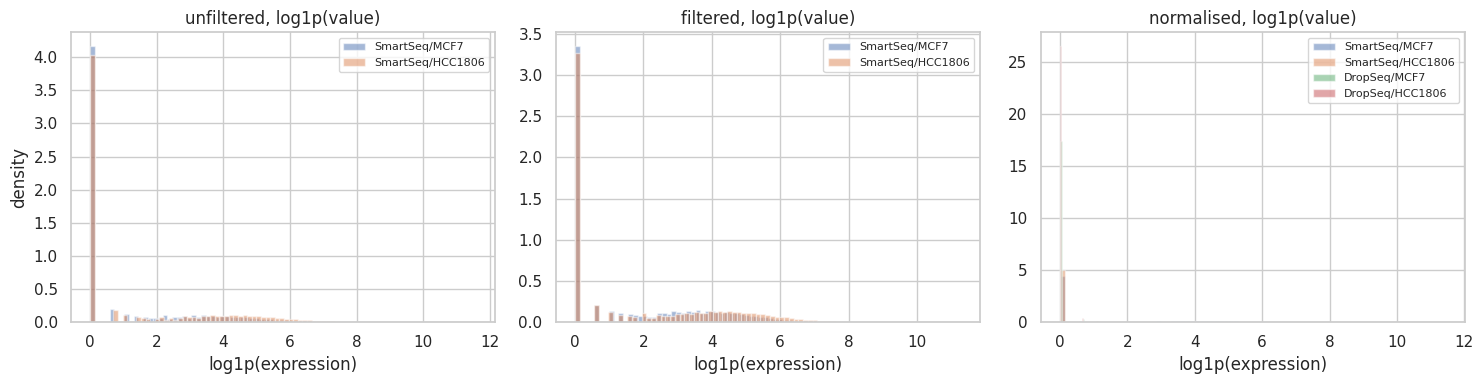

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))  # sharey off: datasets differ hugely in #cells
for ax, stage in zip(axes, ['unfiltered', 'filtered', 'normalised']):
    for (tech, line, s), df in matrices.items():
        if s != stage:
            continue
        sample = df.values.flatten()
        if sample.size > 200_000:
            sample = np.random.default_rng(SEED).choice(sample, 200_000, replace=False)
        ax.hist(np.log1p(sample), bins=80, alpha=0.5, density=True, label=f'{tech}/{line}')
    ax.set_title(f'{stage}, log1p(value)')
    ax.set_xlabel('log1p(expression)')
    ax.legend(fontsize=8)
axes[0].set_ylabel('density')
plt.tight_layout()
plt.show()

### 4.3 Sparsity

scRNA-seq data is dominated by zeros (**dropouts** = genes that are truly expressed but read as 0 because sequencing depth is limited). **Sparsity** = the fraction of entries that are zero. We quantify it per cell and per gene, and compare across technologies and preprocessing stages.

Expectation:
- **Unfiltered** has the most zeros overall.
- **DropSeq** is much sparser than **SmartSeq** at equivalent stages (DropSeq has shallower per-cell sequencing depth).
- Going from *filtered* to *normalised*, the per-matrix sparsity actually goes **up**, not down. That is expected: the "normalised" step keeps the top-3000 *most variable* genes, and highly variable genes are often expressed in only a subset of cells — so the surviving matrix is proportionally more zero-heavy. (An earlier guess that normalisation lowers sparsity was wrong; the numbers below correct it.)

In [7]:
sparsity_rows = []
for (tech, line, stage), df in matrices.items():
    vals = df.values
    sparsity_rows.append({
        'technology': tech, 'cell_line': line, 'stage': stage,
        'overall_frac_zero': float((vals == 0).mean()),
        'median_frac_zero_per_cell': float(np.median((vals == 0).mean(axis=0))),
        'median_frac_zero_per_gene': float(np.median((vals == 0).mean(axis=1))),
    })
sparsity_df = pd.DataFrame(sparsity_rows).sort_values(['technology', 'cell_line', 'stage']).reset_index(drop=True)
sparsity_df

,technology,cell_line,stage,overall_frac_zero,median_frac_zero_per_cell,median_frac_zero_per_gene
0,DropSeq,HCC1806,normalised,0.976376,0.977667,0.996663
1,DropSeq,MCF7,normalised,0.975294,0.977000,0.995468
2,SmartSeq,HCC1806,filtered,0.452056,0.444598,0.414097
3,SmartSeq,HCC1806,normalised,0.706535,0.706167,0.879121
4,SmartSeq,HCC1806,unfiltered,0.558456,0.537058,0.617284
5,SmartSeq,MCF7,filtered,0.471576,0.461441,0.431310
6,SmartSeq,MCF7,normalised,0.636221,0.634333,0.784000
7,SmartSeq,MCF7,unfiltered,0.602153,0.568021,0.673629


### 4.4 Outliers, interquartile range (IQR)

For each cell we compute (a) **library size** = sum of counts, and (b) **detected genes** = number of non-zero entries. The **IQR** is the spread of the middle 50% of values (Q3 − Q1); a value is flagged as an outlier if it lies outside `[Q1 − 1.5·IQR, Q3 + 1.5·IQR]`. We run this on the *unfiltered* SmartSeq data because that is where QC issues should be most visible.

*How to read:* each dot is one cell; red dots are library-size outliers. A cell with a very low library size is likely a dying cell or an empty droplet; a very high one may be a **doublet** (two cells captured as one). These are exactly the cells the supplier's *Filtered* files have already removed — so here the plot is inspection-only, we do not drop anything.

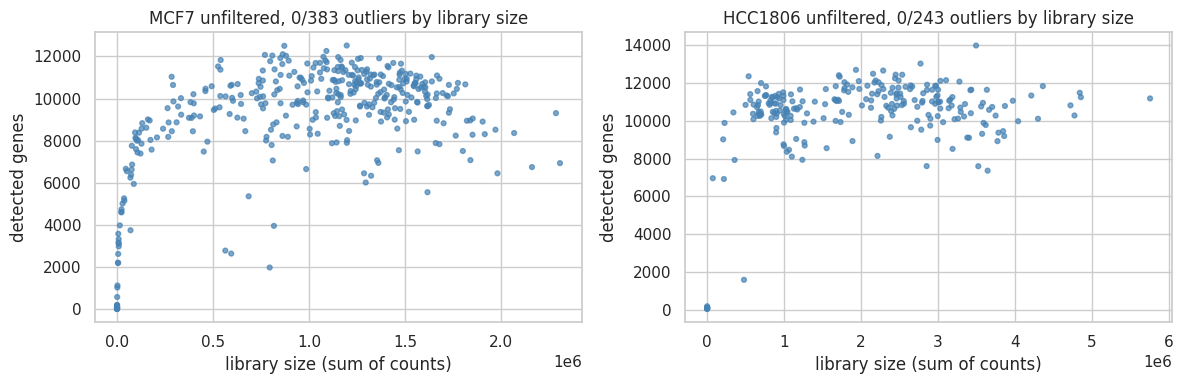

In [8]:
def iqr_flags(series: pd.Series):
    q1, q3 = series.quantile([0.25, 0.75])
    iqr = q3 - q1
    lo, hi = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    return (series < lo) | (series > hi), (lo, hi)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, (label, df) in zip(axes, [('MCF7 unfiltered', matrices[('SmartSeq', 'MCF7', 'unfiltered')]),
                                    ('HCC1806 unfiltered', matrices[('SmartSeq', 'HCC1806', 'unfiltered')])]):
    lib = df.sum(axis=0)
    detected = (df > 0).sum(axis=0)
    flagged, bounds = iqr_flags(lib)
    ax.scatter(lib, detected, c=np.where(flagged, 'red', 'steelblue'), s=12, alpha=0.7)
    ax.set_xlabel('library size (sum of counts)')
    ax.set_ylabel('detected genes')
    ax.set_title(f'{label}, {flagged.sum()}/{len(flagged)} outliers by library size')
plt.tight_layout()
plt.show()

### 4.5 Log transformation

Raw counts span orders of magnitude and have long right tails (most values small, a few very large — **right-skewed**). The standard fix in RNA-seq is the `log1p` transform: `x → log(1 + x)`. The `+1` handles zeros, and the shape becomes much closer to bell-shaped, which makes it friendlier for most ML models (linear models, SVM).

*How to read:* on the left, raw counts pile up near zero with a long tail to the right. On the right, after `log1p`, the same data is roughly symmetric/bell-shaped — the shape linear models and the SVM implicitly assume.

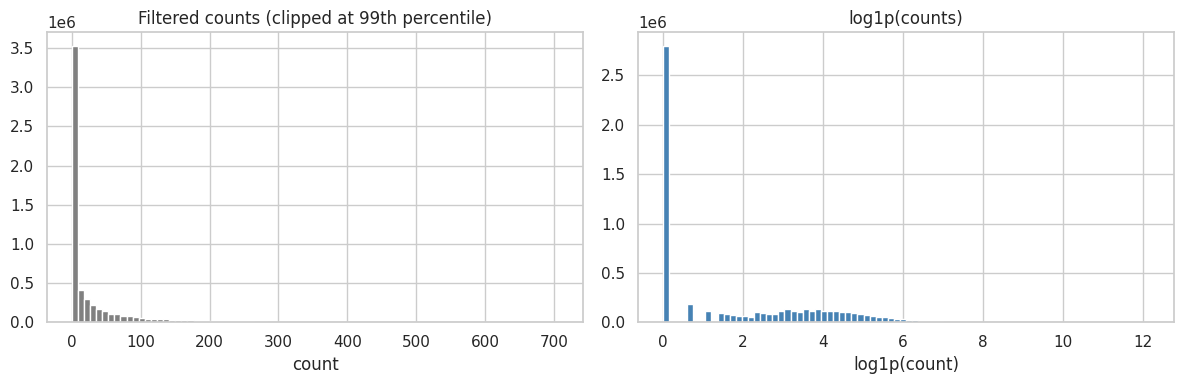

In [9]:
sample_df = matrices[('SmartSeq', 'MCF7', 'filtered')]
raw = sample_df.values.flatten()
logged = np.log1p(raw)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(raw[raw < np.quantile(raw, 0.99)], bins=80, color='grey')
axes[0].set_title('Filtered counts (clipped at 99th percentile)')
axes[0].set_xlabel('count')
axes[1].hist(logged, bins=80, color='steelblue')
axes[1].set_title('log1p(counts)')
axes[1].set_xlabel('log1p(count)')
plt.tight_layout()
plt.show()

### 4.6 Duplicate rows

A duplicated gene row would mean the same gene appears twice in the matrix; a duplicated column would mean two cells have identical expression vectors (suspicious). We check both.

In [10]:
dup_rows = []
for (tech, line, stage), df in matrices.items():
    dup_rows.append({
        'technology': tech, 'cell_line': line, 'stage': stage,
        'dup_gene_rows': int(df.index.duplicated().sum()),
        'dup_cell_cols': int(df.columns.duplicated().sum()),
        'dup_gene_values': int(df.duplicated().sum()),
    })
pd.DataFrame(dup_rows)

,technology,cell_line,stage,dup_gene_rows,dup_cell_cols,dup_gene_values
0,SmartSeq,MCF7,unfiltered,0,0,29
1,SmartSeq,MCF7,filtered,0,0,5
2,SmartSeq,MCF7,normalised,0,0,1
3,SmartSeq,HCC1806,unfiltered,0,0,54
4,SmartSeq,HCC1806,filtered,0,0,16
5,SmartSeq,HCC1806,normalised,0,0,1
6,DropSeq,MCF7,normalised,0,0,0
7,DropSeq,HCC1806,normalised,0,0,0


## 5. Data structure

Here we move from per-value statistics to *relationships between* features (genes) and *between* samples (cells).

- **5.1 Correlation.** Gene-gene Pearson correlation on the top-variable genes.
- **5.2 PCA.** We run PCA to confirm what the course slides already warn: on single-cell expression data with strong sparsity, the first few principal components are often dominated by technical structure (technology, sequencing depth) rather than the biological signal we care about. We look at it two ways — all four subsets together, and each technology on its own.
- **5.3 Heatmap.** Top variable genes across condition, a quick visual for which genes look differentially expressed.

### 5.1 Gene-gene correlation

We compute the **Pearson correlation** (does gene A go up when gene B goes up? +1 = yes, −1 = opposite, 0 = no link) for the top 200 most variable genes of the SmartSeq MCF7 normalised matrix, on `log1p` values, and cluster-order the rows/columns so correlation blocks become visible.

*How to read:* red = genes that rise and fall together, blue = opposite, white = unrelated. Clustering reorders the genes so correlated groups form red square **blocks** along the diagonal — these blocks are co-regulated gene programmes.

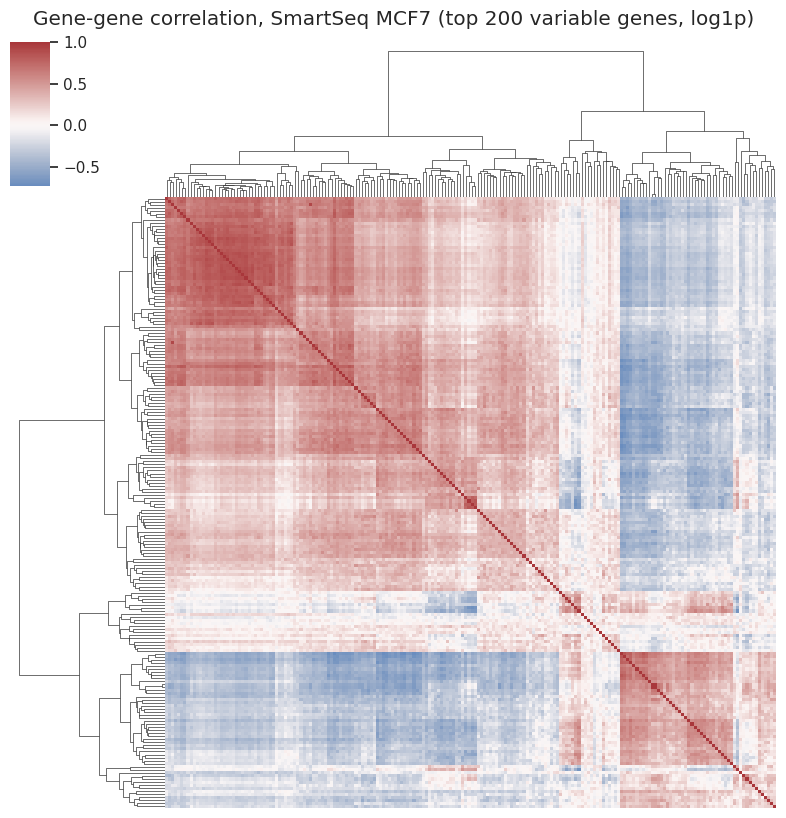

In [11]:
def prep_matrix(df):
    # log1p first: raw counts are heavy-tailed, so a plain Pearson correlation would be
    # dominated by a handful of high-count cells. log1p makes the correlation meaningful.
    X = np.log1p(df.T.astype(float))
    return X

X_mcf7 = prep_matrix(matrices[('SmartSeq', 'MCF7', 'normalised')])
var_genes = X_mcf7.var(axis=0).nlargest(200).index
corr = X_mcf7[var_genes].corr()
g = sns.clustermap(corr, cmap='vlag', center=0, figsize=(8, 8),
                   xticklabels=False, yticklabels=False)
g.fig.suptitle('Gene-gene correlation, SmartSeq MCF7 (top 200 variable genes, log1p)', y=1.02)
plt.show()

### 5.2 PCA

**PCA (Principal Component Analysis)** finds the directions (**principal components**, PCs) along which the data varies most; PC1 captures the most variance, PC2 the next, and so on (the PC axes are unitless mixtures of many genes). We first `log1p` the counts and **standardise** each gene (`StandardScaler`: mean 0, variance 1) so that a few high-expression genes do not dominate.

We look at two views:
- **(a) All four subsets together.** They share only a handful of genes (printed below), because each subset kept its *own* top-3000 variable genes. If the points separate by **technology** more than by **condition**, the strongest signal is a technical **batch effect**, not biology.
- **(b) Each technology on its own.** This removes the large scale gap between SmartSeq and DropSeq and uses many more genes. If hypoxia still does not cleanly separate in 2D even within one technology, that tells us the hypoxia signal is not a simple linear axis — which is exactly why we need the supervised models in §6.

The **scree plot** shows the share of variance each PC explains; a shallow curve (no single dominant PC) means the signal is spread across many directions, typical for sparse scRNA-seq.

Shared genes across all 4 normalised subsets: 70 (small, because each subset kept its own top-3000 variable genes)


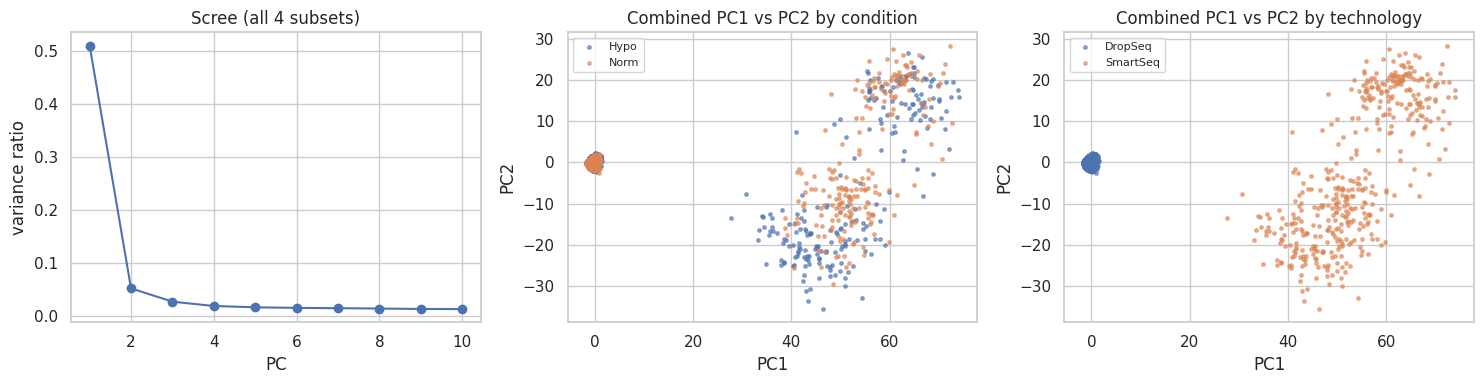

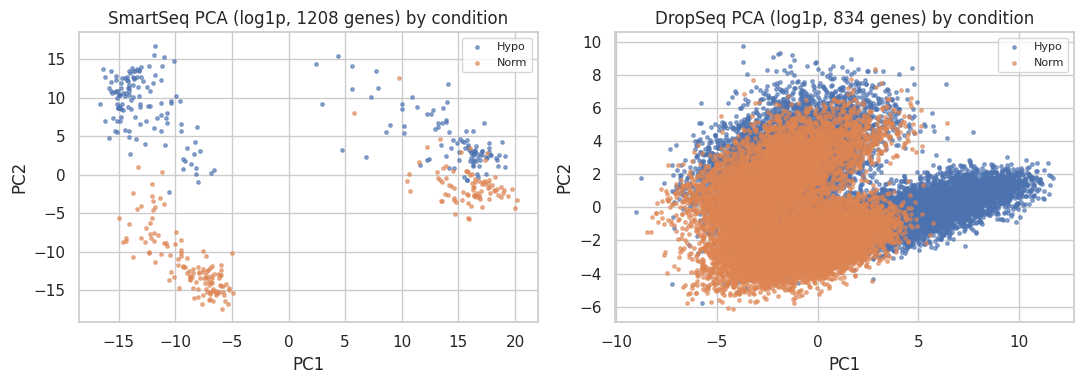

In [12]:
# Cross-subset structures (also re-used by the pooled model in §10.6).
normalised_subsets = {(t, l): matrices[(t, l, 'normalised')]
                      for t in ('SmartSeq', 'DropSeq') for l in ('MCF7', 'HCC1806')}
shared_genes = sorted(set.intersection(*(set(df.index) for df in normalised_subsets.values())))
print(f'Shared genes across all 4 normalised subsets: {len(shared_genes)} '
      f'(small, because each subset kept its own top-3000 variable genes)')

pieces = []
for (tech, line), df in normalised_subsets.items():
    sub = df.loc[shared_genes].T.copy()
    sub['technology'] = tech
    sub['cell_line'] = line
    sub['cell_id'] = sub.index
    pieces.append(sub)
combined = pd.concat(pieces, ignore_index=True)
combined = combined.merge(meta[['cell_id', 'condition']].drop_duplicates('cell_id'), on='cell_id', how='left')

# (a) Combined PCA across all 4 subsets. log1p FIRST (raw counts are heavy-tailed),
#     then standardise each gene so a few high-count genes do not dominate.
Xs = StandardScaler().fit_transform(np.log1p(combined[shared_genes].values.astype(float)))
pca = PCA(n_components=10, random_state=SEED).fit(Xs)
emb = pca.transform(Xs)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].plot(np.arange(1, 11), pca.explained_variance_ratio_, marker='o')
axes[0].set_title('Scree (all 4 subsets)'); axes[0].set_xlabel('PC'); axes[0].set_ylabel('variance ratio')
for ax, colour_by in zip(axes[1:], ['condition', 'technology']):
    for val, sub in combined.groupby(colour_by):
        idx = sub.index.values
        ax.scatter(emb[idx, 0], emb[idx, 1], s=6, alpha=0.6, label=str(val))
    ax.legend(fontsize=8)
    ax.set_title(f'Combined PC1 vs PC2 by {colour_by}')
    ax.set_xlabel('PC1'); ax.set_ylabel('PC2')
plt.tight_layout(); plt.show()

# (b) PCA per technology: removes the large scale gap between SmartSeq and DropSeq,
#     and uses far more than the 4-way shared genes. Coloured by condition.
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, tech in zip(axes, ['SmartSeq', 'DropSeq']):
    g_shared = sorted(set(matrices[(tech, 'MCF7', 'normalised')].index)
                      & set(matrices[(tech, 'HCC1806', 'normalised')].index))
    parts = []
    for line in ('MCF7', 'HCC1806'):
        df = matrices[(tech, line, 'normalised')]
        s = df.loc[g_shared].T.copy(); s['cell_id'] = s.index
        parts.append(s)
    cdf = pd.concat(parts, ignore_index=True)
    cond = labels_by_cell.reindex(cdf['cell_id']).values
    Xt = StandardScaler().fit_transform(np.log1p(cdf[g_shared].values.astype(float)))
    et = PCA(n_components=2, random_state=SEED).fit_transform(Xt)
    for val in ['Hypo', 'Norm']:
        idx = np.where(cond == val)[0]
        ax.scatter(et[idx, 0], et[idx, 1], s=6, alpha=0.6, label=val)
    ax.legend(fontsize=8)
    ax.set_title(f'{tech} PCA (log1p, {len(g_shared)} genes) by condition')
    ax.set_xlabel('PC1'); ax.set_ylabel('PC2')
plt.tight_layout(); plt.show()

### 5.3 Heatmap of top variable genes by condition

A quick check that *some* genes look **differentially expressed** (a gene whose average level differs between hypoxia and normoxia) between Hypo and Norm within a single cell-line/technology subset.

*How to read:* each row is a gene, each column a cell; cells are sorted Hypo vs Norm. Colours are **z-scores** per gene (how far above/below that gene's own average — red = high, blue = low; this is the same per-gene standardisation as the `StandardScaler` used for PCA in §5.2). If a row is mostly red on one side and blue on the other, that gene separates the two conditions.

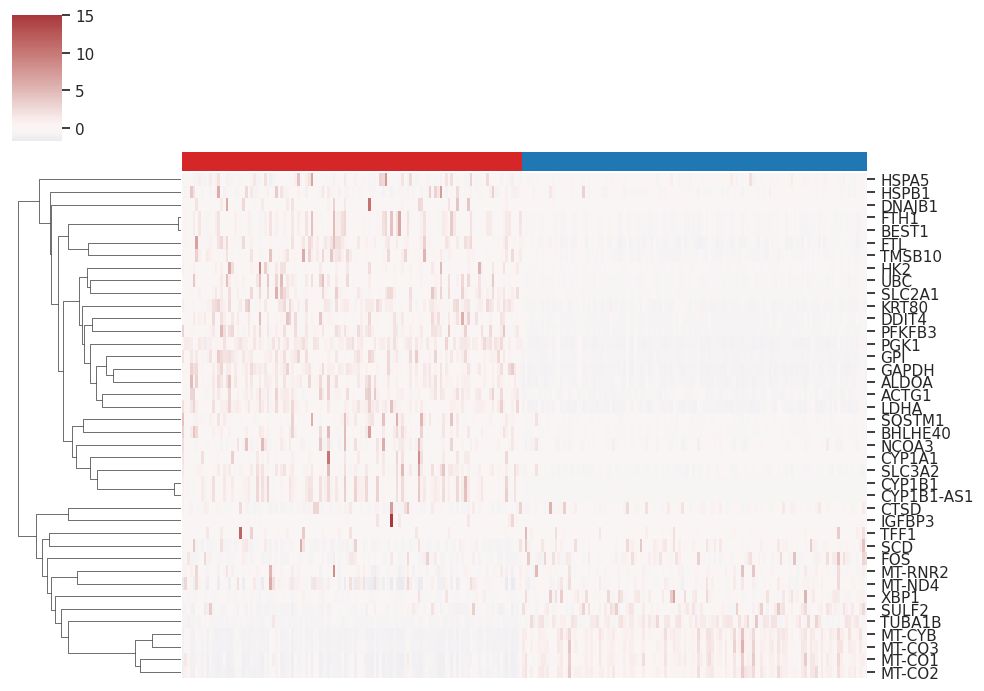

In [13]:
target = matrices[('SmartSeq', 'MCF7', 'normalised')]
labels = labels_by_cell.reindex(target.columns)
sub = target.loc[target.var(axis=1).nlargest(40).index]
col_order = labels.sort_values().index
sub = sub[col_order]
colour_map = labels.reindex(col_order).map({'Hypo': '#d62728', 'Norm': '#1f77b4'})
sns.clustermap(sub, col_cluster=False, z_score=0, cmap='vlag', center=0, figsize=(10, 7),
               col_colors=colour_map.values, yticklabels=True, xticklabels=False)
plt.show()

## 6. Supervised classification

We now predict `Hypo` vs `Norm` from gene expression.

**Evaluation harness.** Every classifier is scored with **Stratified 5-fold CV** on ROC-AUC, accuracy and F1. ROC-AUC is the primary metric because classes can be imbalanced inside individual subsets.

*In plain terms:* **ROC-AUC** runs from 0.5 (random guessing) to 1.0 (perfect ranking); **F1** balances precision and recall; **stratified 5-fold CV** splits the cells into 5 equal, class-balanced parts, trains on 4 and tests on the held-out 5th, rotating until every part has been the test set once. The `StandardScaler` is fit on the training fold only, so no test information leaks in.

**Pipeline per fold.** `StandardScaler → classifier`. The scaler is fit only on the training fold to avoid leakage.

**Classifiers in scope.** Exactly three: **LASSO** (L1-logistic), **Linear SVM**, and a **1D CNN**. Before training, we also build one engineered feature — the **Buffa hypoxia metagene score** — and feed it to all three (see the feature-engineering cell below).

In [14]:
def make_Xy(tech, line, add_buffa=False):
    df = matrices[(tech, line, 'normalised')]
    y = labels_by_cell.reindex(df.columns)
    mask = y.isin(['Hypo', 'Norm']).values
    X = df.T.values[mask]
    genes = list(df.index.values)
    if add_buffa:                                   # append the Buffa metagene score (see 6.1)
        score = buffa_score(df)[mask].reshape(-1, 1)
        X = np.hstack([X, score])
        genes = genes + ['BUFFA_score']
    y = (y[mask] == 'Hypo').astype(int).values
    return X, y, np.array(genes)

def cv_score(clf, X, y, n_splits=5):
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=SEED)
    scores = cross_validate(
        Pipeline([('sc', StandardScaler()), ('clf', clf)]),
        X, y, cv=skf,
        scoring=['roc_auc', 'accuracy', 'f1'],
        return_train_score=False,
    )
    return {k.replace('test_', ''): float(np.mean(v)) for k, v in scores.items() if k.startswith('test_')}

SUBSETS = [('SmartSeq', 'MCF7'), ('SmartSeq', 'HCC1806'), ('DropSeq', 'MCF7'), ('DropSeq', 'HCC1806')]
Xys = {s: make_Xy(*s) for s in SUBSETS}             # raw genes (used by 9 and 11)
for s, (X, y, _) in Xys.items():
    print(f'{s}: X={X.shape}, class balance={np.bincount(y)}')

('SmartSeq', 'MCF7'): X=(250, 3000), class balance=[126 124]
('SmartSeq', 'HCC1806'): X=(182, 3000), class balance=[85 97]
('DropSeq', 'MCF7'): X=(21626, 3000), class balance=[12705  8921]
('DropSeq', 'HCC1806'): X=(14682, 3000), class balance=[5783 8899]


### 6.1 Feature engineering - Buffa hypoxia metagene score

So far every model would see the raw 3000-gene vector. We add **one** engineered feature, kept deliberately simple, and restricted to a single curated gene set.

A **metagene** is a single number that summarises many genes that behave together. We use a **45-gene offline reconstruction of the Buffa hypoxia signature** (Buffa *et al.* 2010; the full published metagene is ~52 genes) — genes that go up when cells run low on oxygen. The **Buffa metagene score** of a cell is the **mean raw expression of the Buffa genes present in that subset**: a high score looks hypoxic, a low score looks normoxic. This single score is then standardised together with the genes inside each model's pipeline, so its larger raw scale does not dominate.

We append this single score as an extra input column for the three supervised models (LASSO, SVM, 1D CNN). It is cheap, interpretable, and a useful sanity check: if a hand-built hypoxia score helps, the models really are picking up hypoxia biology and not just batch artefacts. We do **no** other feature engineering — only this one score, only from the Buffa gene set.

In [15]:
# Buffa et al. (2010) hypoxia metagene: 45-gene offline reconstruction (same list as 10.2).
BUFFA_HYPOXIA = ['ACOT7','ADM','ALDOA','ANKRD37','ANLN','BNIP3','CA9','CDKN3','CHCHD2','CORO1C',
    'CTPS1','DCBLD1','DDIT4','ENO1','ESRP1','FAM83B','GAPDH','GPI','HILPDA','HK2','KIF20A','LDHA',
    'LRRC42','MAD2L2','MCTS1','MIF','MRGBP','MRPL13','MRPS17','NDRG1','P4HA1','PGAM1','PGK1','PSMA7',
    'PSRC1','SHCBP1','SLC16A1','SLC2A1','SLC25A32','TPI1','TUBA1B','TUBB6','VEGFA','YKT6','AK4']

def buffa_score(df):
    """Per-cell Buffa metagene score = mean expression over the Buffa genes present in df.
    df is genes x cells; returns one value per cell (column)."""
    present = [g for g in BUFFA_HYPOXIA if g in df.index]
    return df.loc[present].mean(axis=0).values

# Feature-engineered inputs = raw 3000 genes + the Buffa score column. ONLY the 3 models use these.
Xys_fe = {s: make_Xy(*s, add_buffa=True) for s in SUBSETS}

# Sanity check: how many Buffa genes survive the 3000-gene filter, and is the score alone predictive?
print('Buffa-metagene feature engineering')
for s in SUBSETS:
    df = matrices[(s[0], s[1], 'normalised')]
    n_present = sum(g in df.index for g in BUFFA_HYPOXIA)
    Xfe, yfe, _ = Xys_fe[s]
    score_only = Xfe[:, -1:]                          # just the Buffa score column
    auc_score = cv_score(LogisticRegression(max_iter=1000, random_state=SEED), score_only, yfe)['roc_auc']
    print(f'  {s[0]:8s}/{s[1]:8s}: {n_present:2d}/{len(BUFFA_HYPOXIA)} Buffa genes present | '
          f'Buffa-score-only AUC = {auc_score:.3f}')

Buffa-metagene feature engineering


  SmartSeq/MCF7    : 23/45 Buffa genes present | Buffa-score-only AUC = 1.000
  SmartSeq/HCC1806 : 22/45 Buffa genes present | Buffa-score-only AUC = 0.986


  DropSeq /MCF7    :  8/45 Buffa genes present | Buffa-score-only AUC = 0.826
  DropSeq /HCC1806 : 22/45 Buffa genes present | Buffa-score-only AUC = 0.734


### 6.2 LASSO (L1 logistic regression)

We use `GridSearchCV` over `LogisticRegression(penalty='l1', solver='saga')` to pick the regularisation strength `C` (smaller `C` = stronger penalty = fewer genes kept) from a 20-point log grid via 3-fold inner CV. This is equivalent to `LogisticRegressionCV` but goes through the `cuml.accel`-proxied `LogisticRegression`, so the fits run on GPU. L1 drives most coefficients to zero, the non-zero ones are the genes LASSO found useful for discriminating Hypo vs Norm.

We record stability: a gene selected in every fold matters more than one selected once.

In [16]:
LASSO_CS = np.logspace(-4, 4, 20)

def lasso_fit(X, y, genes):
    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
    selected = np.zeros(X.shape[1], dtype=int)
    aucs = []
    for tr, te in skf.split(X, y):
        sc = StandardScaler().fit(X[tr])
        Xtr = sc.transform(X[tr]).astype('float32')
        Xte = sc.transform(X[te]).astype('float32')
        gs = GridSearchCV(
            LogisticRegression(penalty='l1', solver='saga', max_iter=3000, random_state=SEED),
            {'C': LASSO_CS}, cv=3, scoring='roc_auc', n_jobs=1,
        ).fit(Xtr, y[tr])
        clf = gs.best_estimator_
        prob = clf.predict_proba(Xte)[:, 1]
        aucs.append(roc_auc_score(y[te], prob))
        selected += (clf.coef_[0] != 0).astype(int)
    stability = pd.Series(selected / 5, index=genes).sort_values(ascending=False)
    return float(np.mean(aucs)), stability

lasso_results = {}
for subset, (X, y, g) in Xys_fe.items():
    auc, stab = lasso_fit(X, y, g)
    lasso_results[subset] = {'auc': auc, 'top_genes': stab.head(20)}
    print(f'LASSO {subset}: AUC={auc:.3f}, non-zero (>=80% folds) = {(stab >= 0.8).sum()}')

print('\nTop stable genes for SmartSeq/MCF7:')
print(lasso_results[('SmartSeq', 'MCF7')]['top_genes'].head(15))

LASSO ('SmartSeq', 'MCF7'): AUC=1.000, non-zero (>=80% folds) = 6


LASSO ('SmartSeq', 'HCC1806'): AUC=0.987, non-zero (>=80% folds) = 10


[2026-06-04 22:54:18.799] [CUML] [warning] QWL-QN stopped, because the line search failed to advance (step delta = 0.000000)


[2026-06-04 22:54:36.771] [CUML] [warning] QWL-QN stopped, because the line search failed to advance (step delta = 0.000000)


[2026-06-04 22:54:49.362] [CUML] [warning] QWL-QN line search failed (code 3); stopping at the last valid step


...

[2026-06-04 22:57:05.568] [CUML] [warning] QWL-QN stopped, because the line search failed to advance (step delta = 0.000000)


[2026-06-04 22:58:11.846] [CUML] [warning] QWL-QN stopped, because the line search failed to advance (step delta = 0.000000)


[2026-06-04 22:58:40.884] [CUML] [warning] QWL-QN stopped, because the line search failed to advance (step delta = 0.000000)


[2026-06-04 22:58:41.256] [CUML] [warning] QWL-QN line search failed (code 3); stopping at the last valid step


LASSO ('DropSeq', 'HCC1806'): AUC=0.990, non-zero (>=80% folds) = 571

Top stable genes for SmartSeq/MCF7:
SLC25A39       1.0
PGK1           1.0
BUFFA_score    1.0
MT-CYB         1.0
PFKP           1.0
SNRNP25        0.8
PGP            0.4
HNRNPA2B1      0.4
DHCR7          0.4
FAM162A        0.4
SULT2B1        0.2
SLC52A2        0.2
ZNF395         0.2
NECTIN2        0.2
SCARB1         0.2
dtype: float64


### 6.3 Linear SVM

`LinearSVC` with default C. It is a non-probabilistic classifier, so to get ROC-AUC we wrap it in `CalibratedClassifierCV` which fits a sigmoid on top of the margin.

In [17]:
svm_results = {}
for subset, (X, y, g) in Xys_fe.items():
    base = LinearSVC(C=1.0, random_state=SEED, max_iter=5000)
    clf = CalibratedClassifierCV(base, cv=3)
    svm_results[subset] = cv_score(clf, X, y)
    print(f'SVM {subset}: AUC={svm_results[subset]["roc_auc"]:.3f}  Acc={svm_results[subset]["accuracy"]:.3f}')

SVM ('SmartSeq', 'MCF7'): AUC=1.000  Acc=1.000


SVM ('SmartSeq', 'HCC1806'): AUC=0.993  Acc=0.962


SVM ('DropSeq', 'MCF7'): AUC=0.995  Acc=0.972


SVM ('DropSeq', 'HCC1806'): AUC=0.980  Acc=0.927


### 6.4 1D CNN

Small PyTorch model: `Conv1d(1→16, kernel=7) → Conv1d(16→16, kernel=7) → AvgPool → Linear(→2)`. Genes are input in decreasing-variance order (an arbitrary but reproducible 1D ordering, since we have no chromosomal coordinates).

*Why a CNN, and how to read it:* a 1D convolution slides a small learnable filter along the gene vector, letting the model combine *neighbouring* positions non-linearly. Because the gene order is arbitrary, the CNN is an **exploratory** non-linear baseline rather than a biologically-motivated model — we expect it to be weaker and noisier than the linear models, which it is.

In [18]:
def train_cnn_fold(Xtr, ytr, Xte, yte, epochs=25, batch=256, lr=1e-3, seed=SEED):
    device = DEVICE
    use_amp = (device.type == 'cuda')

    class CNN(nn.Module):
        def __init__(self):
            super().__init__()
            self.net = nn.Sequential(
                nn.Conv1d(1, 16, kernel_size=7, padding=3), nn.ReLU(),
                nn.Conv1d(16, 16, kernel_size=7, padding=3), nn.ReLU(),
                nn.AdaptiveAvgPool1d(64), nn.Flatten(),
                nn.Linear(16 * 64, 32), nn.ReLU(),
                nn.Linear(32, 2))
        def forward(self, x):
            return self.net(x)

    torch.manual_seed(seed)
    model = CNN().to(device)
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    loss_fn = nn.CrossEntropyLoss()

    Xtr_t = torch.tensor(np.asarray(Xtr), dtype=torch.float32, device=device).unsqueeze(1)
    ytr_t = torch.tensor(np.asarray(ytr), dtype=torch.long,    device=device)
    Xte_t = torch.tensor(np.asarray(Xte), dtype=torch.float32, device=device).unsqueeze(1)

    n = Xtr_t.shape[0]
    for _ in range(epochs):
        model.train()
        order = torch.randperm(n, device=device)
        for i in range(0, n, batch):
            idx = order[i:i+batch]
            opt.zero_grad(set_to_none=True)
            with torch.autocast(device_type='cuda', dtype=torch.bfloat16, enabled=use_amp):
                loss = loss_fn(model(Xtr_t[idx]), ytr_t[idx])
            loss.backward()
            opt.step()
    model.eval()
    with torch.no_grad():
        prob = torch.softmax(model(Xte_t).float(), dim=1).cpu().numpy()[:, 1]
    return roc_auc_score(yte, prob)

cnn_results = {}
if TORCH_OK:
    for subset, (X, y, g) in Xys_fe.items():
        order = np.argsort(-X.var(axis=0))
        Xo = X[:, order]
        skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
        aucs = []
        for tr, te in skf.split(Xo, y):
            sc = StandardScaler().fit(Xo[tr])
            Xtr = np.asarray(sc.transform(Xo[tr])).astype('float32')
            Xte = np.asarray(sc.transform(Xo[te])).astype('float32')
            aucs.append(train_cnn_fold(Xtr, y[tr], Xte, y[te]))
        cnn_results[subset] = {'roc_auc': float(np.mean(aucs))}
        print(f'1D CNN {subset}: AUC={cnn_results[subset]["roc_auc"]:.3f}')
else:
    print('PyTorch not installed - 1D CNN section skipped.')


1D CNN ('SmartSeq', 'MCF7'): AUC=0.859


1D CNN ('SmartSeq', 'HCC1806'): AUC=0.728


1D CNN ('DropSeq', 'MCF7'): AUC=0.951


1D CNN ('DropSeq', 'HCC1806'): AUC=0.778


### 6.5 Comparison across classifiers

One table per subset, one column per classifier (AUC). A useful sanity check: within-subset AUC is almost always high on this kind of data. The honest test comes in §7 (cross-subset).

In [19]:
compare = {}
for subset in SUBSETS:
    row = {'LASSO': lasso_results[subset]['auc'],
           'SVM':   svm_results[subset]['roc_auc']}
    if subset in cnn_results:
        row['1D CNN'] = cnn_results[subset]['roc_auc']
    compare[f'{subset[0]}/{subset[1]}'] = row
compare_df = pd.DataFrame(compare).T
compare_df.style.background_gradient(cmap='Blues').format('{:.3f}')

,LASSO,SVM,1D CNN
SmartSeq/MCF7,1.000,1.000,0.859
SmartSeq/HCC1806,0.987,0.993,0.728
DropSeq/MCF7,0.997,0.995,0.951
DropSeq/HCC1806,0.990,0.980,0.778


## 7. Cross-cell-line and cross-technology generalisation

This is the most important experiment in the report. Within each subset, the classifier almost certainly gets very high AUC, but that does *not* mean we found a biological hypoxia signature; it might just mean the model memorised the batch.

We now train on one (cell-line, technology) subset and evaluate on a different one. To do that we must restrict both matrices to the *intersection* of their gene sets. We run this for **LASSO**, our interpretable baseline: if AUC stays high across subsets, the signature generalises; if it collapses, the classifier was fitting technology/cell-line artefacts.

In [20]:
def cross_eval(src, dst, model_fn):
    df_s = matrices[(src[0], src[1], 'normalised')]
    df_d = matrices[(dst[0], dst[1], 'normalised')]
    shared = sorted(set(df_s.index) & set(df_d.index))
    y_s = labels_by_cell.loc[df_s.columns]
    y_d = labels_by_cell.loc[df_d.columns]
    ms = y_s.isin(['Hypo', 'Norm']).values
    md = y_d.isin(['Hypo', 'Norm']).values
    Xs = df_s.loc[shared].T.values[ms]
    Xd = df_d.loc[shared].T.values[md]
    ys = (y_s[ms] == 'Hypo').astype(int).values
    yd = (y_d[md] == 'Hypo').astype(int).values
    sc = StandardScaler().fit(Xs)
    clf = model_fn().fit(sc.transform(Xs).astype('float32'), ys)
    Xd_t = sc.transform(Xd).astype('float32')
    if hasattr(clf, 'predict_proba'):
        prob = clf.predict_proba(Xd_t)[:, 1]
    else:
        prob = clf.decision_function(Xd_t)
    return roc_auc_score(yd, prob), len(shared)

def make_lasso_gs():
    return GridSearchCV(
        LogisticRegression(penalty='l1', solver='saga', max_iter=2000, random_state=SEED),
        {'C': np.logspace(-3, 3, 10)}, cv=3, scoring='roc_auc', n_jobs=1,
    )

models = {
    'LASSO': make_lasso_gs,
}

rows = []
for name, mfn in models.items():
    for src in SUBSETS:
        for dst in SUBSETS:
            if src == dst:
                continue
            auc, n_shared = cross_eval(src, dst, mfn)
            rows.append({'model': name,
                         'train': f'{src[0]}/{src[1]}',
                         'test':  f'{dst[0]}/{dst[1]}',
                         'n_shared_genes': n_shared,
                         'auc': auc})
gen_df = pd.DataFrame(rows)
for name in models:
    pivot = gen_df[gen_df.model == name].pivot(index='train', columns='test', values='auc')
    print(f'\n== {name} cross-subset AUC ==')
    print(pivot.round(3))

[2026-06-04 23:02:05.002] [CUML] [warning] QWL-QN stopped, because the line search failed to advance (step delta = 0.000000)


[2026-06-04 23:02:16.392] [CUML] [warning] QWL-QN stopped, because the line search failed to advance (step delta = 0.000000)



== LASSO cross-subset AUC ==
test              DropSeq/HCC1806  DropSeq/MCF7  SmartSeq/HCC1806  SmartSeq/MCF7
train                                                                           
DropSeq/HCC1806               NaN         0.791             0.665          0.897
DropSeq/MCF7                0.537           NaN             0.664          0.980
SmartSeq/HCC1806            0.742         0.673               NaN          0.998
SmartSeq/MCF7               0.658         0.714             0.947            NaN


## 8. Prediction on unseen (anonymised) test data

The course provides `*_test_anonim.txt` files for both technologies and both cell lines. Their columns are renumbered so we cannot see the hypoxia labels. We use our best in-subset classifier (LASSO) to produce predictions and save them as a tab-separated file the course can grade against the hidden labels. (For these submitted predictions the LASSO is trained on the raw 3000 genes only — without the engineered Buffa column — so the pipeline stays simple and robust on the anonymised test files.)

> Note: if the test set is released later with a different schema, only the loading step changes.

In [21]:
test_paths = {
    ('SmartSeq', 'MCF7'):    SMART / 'MCF7_SmartS_Filtered_Normalised_3000_Data_test_anonim.txt',
    ('SmartSeq', 'HCC1806'): SMART / 'HCC1806_SmartS_Filtered_Normalised_3000_Data_test_anonim.txt',
    ('DropSeq',  'MCF7'):    DROP  / 'MCF7_Filtered_Normalised_3000_Data_test_anonim.txt',
    ('DropSeq',  'HCC1806'): DROP  / 'HCC1806_Filtered_Normalised_3000_Data_test_anonim.csv',
}

pred_frames = []
for subset, path in test_paths.items():
    if not path.exists():
        print(f'[skip] {path.name} missing')
        continue
    X_tr, y_tr, g_tr = Xys[subset]
    sc = StandardScaler().fit(X_tr)
    Xtr_t = sc.transform(X_tr).astype('float32')
    clf = GridSearchCV(
        LogisticRegression(penalty='l1', solver='saga', max_iter=3000, random_state=SEED),
        {'C': np.logspace(-3, 3, 10)}, cv=3, scoring='roc_auc', n_jobs=1,
    ).fit(Xtr_t, y_tr).best_estimator_
    test_df = load_expr(path)
    shared = [g for g in g_tr if g in test_df.index]
    if len(shared) < len(g_tr):
        missing = [g for g in g_tr if g not in test_df.index]
        fill = pd.DataFrame(0.0, index=missing, columns=test_df.columns)
        test_df = pd.concat([test_df, fill]).loc[g_tr]
    else:
        test_df = test_df.loc[g_tr]
    Xte = sc.transform(test_df.T.values).astype('float32')
    prob = clf.predict_proba(Xte)[:, 1]
    pred = pd.DataFrame({'cell_id': test_df.columns,
                         'technology': subset[0], 'cell_line': subset[1],
                         'prob_hypo': prob,
                         'pred': np.where(prob >= 0.5, 'Hypo', 'Norm')})
    pred_frames.append(pred)

if pred_frames:
    predictions = pd.concat(pred_frames, ignore_index=True)
    predictions.to_csv(OUT_DIR / 'predictions.tsv', sep='\t', index=False)
    print(f'Wrote {len(predictions)} predictions to {(OUT_DIR / "predictions.tsv").resolve()}')
    predictions.head()
else:
    print('No test files found on disk.')

[2026-06-04 23:03:04.137] [CUML] [warning] QWL-QN stopped, because the line search failed to advance (step delta = 0.000000)


Wrote 9185 predictions to /mnt/c/Users/ricca/OneDrive/universita/4_semestre/AI_lab/ai-lab-gene-expression/outputs/predictions.tsv


## 9. Conclusions

Within every (cell-line × technology) subset, the three classifiers separate hypoxia from normoxia with high accuracy — LASSO and Linear SVM reach AUC ≈ 0.96–1.00, while the 1D-CNN is lower and more variable (§6.5). High within-subset accuracy alone proves only that the signal is *easy to fit*, not that it is biological. The real evidence comes from generalisation and from the genes themselves, and it tells one consistent, qualified story.

**1. Within-subset accuracy is high and therefore uninformative on its own** (the linear models reach AUC ~0.98–1.00). The engineered **Buffa metagene score alone** already separates the classes well within each subset (the feature-engineering cell in §6), an early sign that the signal is genuinely hypoxic rather than a fitting artefact (the Buffa-score-alone AUC is a near-perfect 1.000 / 0.986 on the small, balanced SmartSeq subsets — reflecting easy linear separability there — and a more informative 0.826 / 0.734 on the larger DropSeq sets).

**2. Train-on-one-cell-line / test-on-the-other (§7, §10.6) splits sharply by technology.**
- *Within SmartSeq* it is excellent: MCF7 → HCC1806 = **0.947**, HCC1806 → MCF7 = **0.998**. A signature learned on one cell line works on the other.
- *Within DropSeq* it is weak and asymmetric: HCC1806 → MCF7 = 0.791 but MCF7 → HCC1806 = **0.537** (≈ chance). DropSeq's sparser, noisier UMI data limits transfer — it also drives LASSO to retain many more genes than SmartSeq's compact ~10–20.

**3. Cross-technology transfer is lower and variable**, matching the EDA where technology dominates PC1–PC2 — a batch effect, not biology.

**4. A single pooled model (§10.6) confirms it.** Pooled *within* a technology, leave-one-cell-line-out: SmartSeq LASSO ≈ **0.95–1.00** (held-out 0.947 / 0.998, mean 0.97); DropSeq ≈ **0.66** (mean 0.659). Pooled across *all four* subsets, leave-one-subset-out, **LASSO collapses to ≈ 0.62**: a single linear model cannot absorb the cross-technology shift. The signal is learnable but technology-confounded; deploying one classifier across platforms would need explicit **batch correction** (per-subset z-scoring / ComBat / integration) before pooling — the natural next step.

**5. The predictive genes are genuinely hypoxic (§10.1-10.5).** **PGK1** is predictive in all four subsets and is the single shared core (computed on the top-50-capped predictive sets, so the hard intersection of one gene is conditional on that cap); glycolysis dominates the pathway breakdown (PGK1, GAPDH, ENO1, TPI1, ALDOA), with classic HIF targets alongside (BNIP3, DDIT4, P4HA1, NDRG1). Every (subset × signature) overlap with the published hypoxia sets (Buffa, Hallmark, Winter, curated HIF) is significant after BH-FDR — so the classifiers exploit the real hypoxia programme.

**Verdict.** Hypoxia is robustly detectable from single-cell expression, and the responsible genes are the canonical glycolytic / HIF programme (PGK1 foremost). A transferable biomarker is well-supported *within a technology* — strongly for SmartSeq — while *across* technologies the batch effect dominates a single linear model. For a deployable cross-platform hypoxia classifier the data argue for explicit batch correction before pooling.

**Caveats.** Cells are not independent, so within-subset CV is optimistic; the trustworthy numbers are the cross-cell-line, cross-technology and leave-one-group-out results. GPU estimators (cuML LASSO/SVM, torch CNN) are not bit-reproducible, so AUCs can wobble by ~0.005 run-to-run. The published signatures are reconstructed offline (flagged `VERIFY-MSIGDB`); the overlap *pattern* (glycolysis-centred, recurrent, significant across tests) is robust even if individual memberships need MSigDB confirmation.

## 10. Feature importance, biological interpretation & combined-cell-line model

Sections 6-8 showed that every classifier separates Hypo from Norm almost perfectly *within* a subset, that the signal partly transfers across cell lines, and that it degrades across technologies. High within-subset accuracy alone is **not** evidence of a biological hypoxia signature: a model can exploit a purely technical/batch artefact and still score AUC ~ 1. This section provides the missing evidence by answering three questions:

1. **Which genes** do the models actually rely on? (&sect;10.1 - feature importance)
2. Do those genes **recover the known hypoxia programme**? (&sect;10.2-10.4 - signature overlap & pathway breakdown)
3. Is there a **core set shared across all four subsets**, and does a single **pooled** model generalise to a *held-out* cell line? (&sect;10.5-10.6)

> **Offline / reproducibility note.** Everything here runs with **no network access**. Published hypoxia signatures (Buffa, Hallmark, Winter) are **reconstructed from the literature and hardcoded** below; they are flagged `VERIFY-MSIGDB` and should be re-checked against the canonical MSigDB `.gmt` files before final submission (the Hallmark set is a high-confidence *core*, not the full ~200-gene collection). Enrichment is therefore done as an exact **hypergeometric overlap test against each subset's own measured ~3000-gene panel** (the test background is that ~3000-gene panel; the ~8645-gene figure is only the *union* across the four subsets, reported in §10.2 as the overall measured universe, and is **not** the test background) rather than via online tools (Enrichr/GSEA). This is in fact the statistically correct comparison for a panel that was *already* pre-filtered to the top-3000 most-variable genes, where the whole-genome background assumed by Enrichr/GSEA would badly inflate significance.

### 10.1 Feature importance - what each model relies on

We extract a ranked predictive-gene list from our two **interpretable** classifiers (the 1D CNN is not weight-interpretable, so it is excluded here):

- **LASSO** - *selection stability* (fraction of 5 CV folds in which the L1 coefficient is non-zero) and *mean |coefficient|*, at a fixed `C = 0.1` (the tuned-AUC version lives in §6.2; here we only need stable coefficients, so we skip the inner grid search).
- **Linear SVM** - absolute weights `|coef_|` of a `LinearSVC` on standardised input.

A **consensus** rank (mean percentile rank across the two) is the headline: a gene ranked highly by LASSO *and* SVM is more credible than one picked by a single model. (Importance is computed on the raw genes only — the engineered Buffa score is excluded so the ranking is purely gene-level.)

The working *predictive signature* per subset is the LASSO-stable set ranked by this consensus and **capped at the top 50** genes, so the four signatures are comparable in size (close to Buffa's compact published metagene). We also report the **raw** stable count: SmartSeq selects a naturally compact set (~10-20 genes) whereas the sparser, noisier DropSeq UMI data drives LASSO to retain many more - a contrast that itself foreshadows the weaker DropSeq generalisation seen later.

In [22]:
LASSO_C_IMP = 0.1   # fixed L1 strength for importance extraction (tuned-AUC LASSO is in 6.2)

def lasso_importance(X, y, genes, C=LASSO_C_IMP):
    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
    sel = np.zeros(X.shape[1]); coef = np.zeros(X.shape[1])
    for tr, _ in skf.split(X, y):
        sc = StandardScaler().fit(X[tr])
        clf = LogisticRegression(penalty='l1', solver='saga', C=C, max_iter=4000,
                                 random_state=SEED).fit(sc.transform(X[tr]).astype('float32'), y[tr])
        c = clf.coef_[0]; sel += (np.abs(c) > 1e-6); coef += np.abs(c)
    return pd.Series(sel / 5, index=genes), pd.Series(coef / 5, index=genes)

def svm_importance(X, y, genes):
    sc = StandardScaler().fit(X)
    svc = LinearSVC(C=1.0, random_state=SEED, max_iter=5000).fit(sc.transform(X).astype('float32'), y)
    return pd.Series(np.abs(svc.coef_[0]), index=genes)

IMPORTANCE = {}
for s in SUBSETS:
    X, y, g = Xys[s]                 # raw genes only (no engineered Buffa column)
    stab, coef = lasso_importance(X, y, g)
    IMPORTANCE[s] = {'lasso_stab': stab, 'lasso_coef': coef, 'svm': svm_importance(X, y, g)}
    print(f'{s[0]:8s}/{s[1]:8s}: LASSO stable(>=0.6)={int((stab >= 0.6).sum()):3d} | '
          f'top SVM={IMPORTANCE[s]["svm"].idxmax():10s}')

SmartSeq/MCF7    : LASSO stable(>=0.6)= 17 | top SVM=PGK1      


SmartSeq/HCC1806 : LASSO stable(>=0.6)= 11 | top SVM=BNIP3     


DropSeq /MCF7    : LASSO stable(>=0.6)=822 | top SVM=MT-RNR2   


DropSeq /HCC1806 : LASSO stable(>=0.6)=1139 | top SVM=NDRG1     


In [23]:
def consensus_rank(imp):
    R = pd.DataFrame({'LASSO': imp['lasso_coef'].rank(pct=True),
                      'SVM':   imp['svm'].rank(pct=True)})
    R['consensus'] = R[['LASSO', 'SVM']].mean(axis=1)
    return R.sort_values('consensus', ascending=False)

CONSENSUS = {s: consensus_rank(IMPORTANCE[s]) for s in SUBSETS}

# Predictive-gene set per subset: LASSO-stable genes, ranked by the LASSO+SVM consensus and
# capped at TOP_K so the four signatures are comparable (cf. Buffa's compact metagene, ~50 genes).
# We also report the RAW stable count: SmartSeq is sparse (a naturally compact signature) while
# DropSeq selects many more genes (sparser, noisier UMI data) - an informative contrast in itself.
STAB_THR = 0.6
TOP_K    = 50
PRED = {}
for s in SUBSETS:
    stab = IMPORTANCE[s]['lasso_stab']
    stable = stab[stab >= STAB_THR].index
    if len(stable) < 10:
        stable = CONSENSUS[s].head(100).index          # fallback when LASSO is too sparse
    ranked = CONSENSUS[s].loc[CONSENSUS[s].index.isin(stable)].index.tolist()
    PRED[s] = ranked[:TOP_K]
    print(f'{s[0]:8s}/{s[1]:8s}: {int((stab >= STAB_THR).sum()):4d} LASSO-stable -> '
          f'top-{len(PRED[s])} signature | {", ".join(PRED[s][:8])}')

SmartSeq/MCF7    :   17 LASSO-stable -> top-17 signature | PGK1, MT-CYB, FAM162A, PFKP, GAPDH, EMP2, MT-CO2, FDPS
SmartSeq/HCC1806 :   11 LASSO-stable -> top-11 signature | PGK1, DDIT4, BNIP3, ALDOA, BNIP3L, P4HA1, FAM162A, BHLHE40
DropSeq /MCF7    :  822 LASSO-stable -> top-50 signature | MT-RNR2, TFF1, GAPDH, PGK1, MT-RNR1, KRT19, LGALS1, TMSB10
DropSeq /HCC1806 : 1139 LASSO-stable -> top-50 signature | NDRG1, IGFBP3, FGF23, BCYRN1, GPM6A, LDHA, AKR1C2, EGLN3


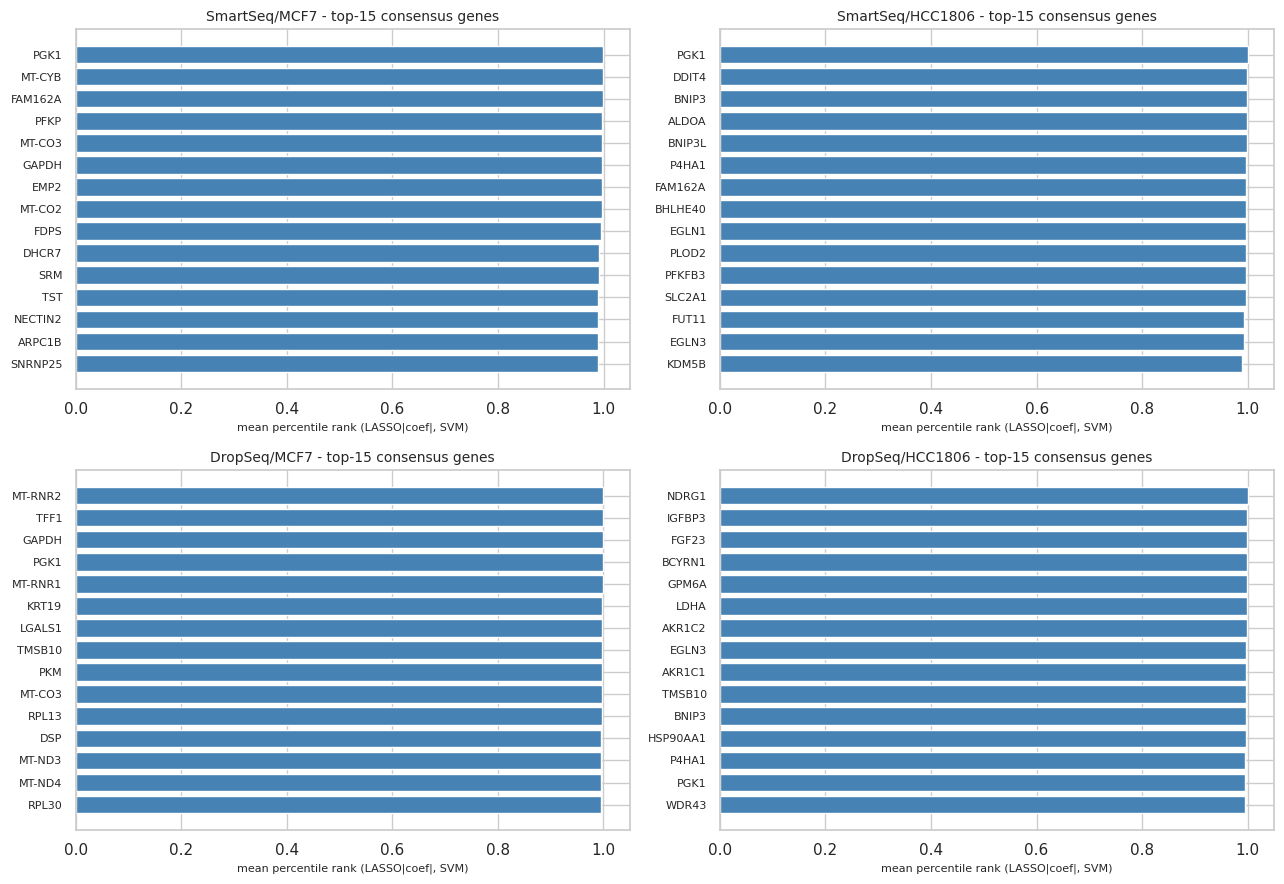

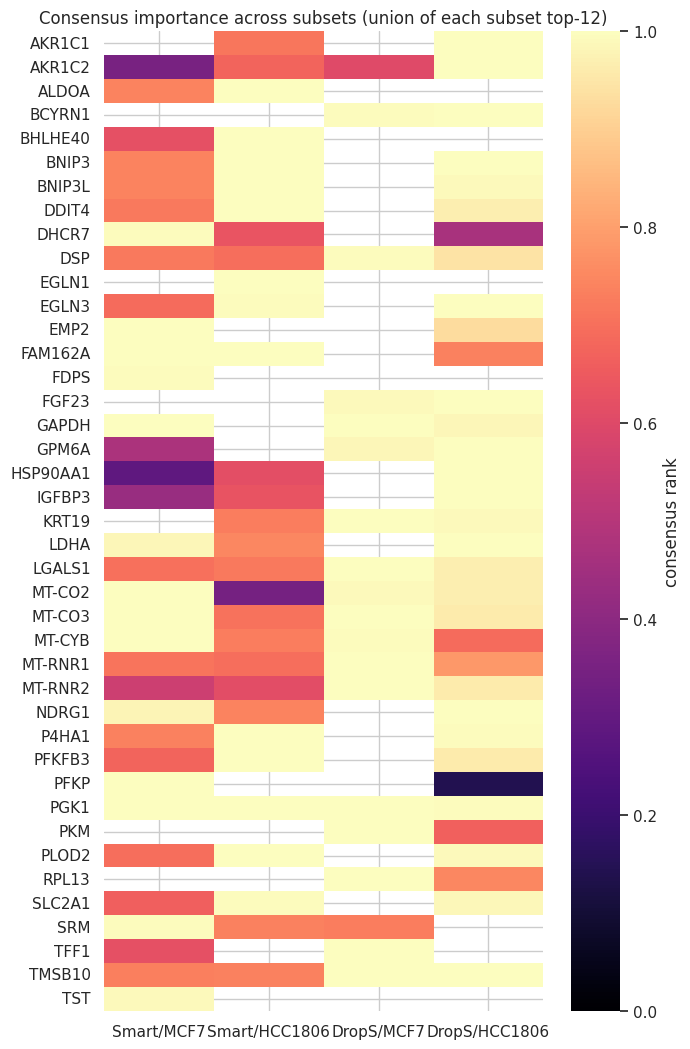

In [24]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9))
for ax, s in zip(axes.ravel(), SUBSETS):
    top = CONSENSUS[s].head(15)['consensus'].iloc[::-1]
    ax.barh(range(len(top)), top.values, color='steelblue')
    ax.set_yticks(range(len(top))); ax.set_yticklabels(top.index, fontsize=8)
    ax.set_title(f'{s[0]}/{s[1]} - top-15 consensus genes', fontsize=10)
    ax.set_xlabel('mean percentile rank (LASSO|coef|, SVM)', fontsize=8)
plt.tight_layout(); plt.show()

top_union = sorted(set().union(*[set(CONSENSUS[s].head(12).index) for s in SUBSETS]))
H = pd.DataFrame({f'{s[0][:5]}/{s[1]}': CONSENSUS[s]['consensus'].reindex(top_union) for s in SUBSETS})
fig, ax = plt.subplots(figsize=(7, max(4, len(top_union) * 0.26)))
sns.heatmap(H, cmap='magma', vmin=0, vmax=1, ax=ax, cbar_kws={'label': 'consensus rank'})
ax.set_title('Consensus importance across subsets (union of each subset top-12)')
plt.tight_layout(); plt.show()

### 10.2 Reference hypoxia signatures (reconstructed offline)

To ask whether the predictive genes are *biologically* hypoxic we compare them to four reference sets:

| Set | What it is | Provenance here |
|-----|------------|-----------------|
| `HIF_targets_curated` | Canonical HIF-1 direct targets, grouped by programme (glycolysis, angiogenesis, pH, survival, ...) | Curated from review literature (Semenza; Harris) - high confidence |
| `BUFFA_HYPOXIA` | Buffa *et al.* 2010 prognostic hypoxia metagene (~52 published; 45-gene offline reconstruction here) | `VERIFY-MSIGDB` - reconstructed |
| `HALLMARK_HYPOXIA_core` | High-confidence **core** of MSigDB `HALLMARK_HYPOXIA` (NOT the full ~200) | `VERIFY-MSIGDB` - reconstructed, partial |
| `WINTER_HYPOXIA` | Compact Winter *et al.* hypoxia set | `VERIFY-MSIGDB` - reconstructed |

The Buffa metagene is especially apt: F. M. Buffa (the course instructor) derived it as a *compact, transferable, pan-cancer* hypoxia signature - exactly the property we are testing for here. We first report **coverage**: how many signature genes even survive into our 3000-gene panel. "Only k/45 Buffa genes are measured" is itself a finding and caps the maximum achievable overlap.

In [25]:
HIF_TARGETS = {
    'glycolysis':         ['SLC2A1','SLC2A3','HK1','HK2','PFKL','PFKFB3','ALDOA','ALDOC','GAPDH','PGK1','PGAM1','ENO1','TPI1','LDHA','PDK1'],
    'angiogenesis':       ['VEGFA','VEGFC','ANGPT2','ANGPTL4','FLT1','KDR','NRP1','EDN1'],
    'pH_regulation':      ['CA9','CA12','SLC9A1','SLC16A1','SLC16A3'],
    'survival_autophagy': ['BNIP3','BNIP3L','HILPDA','DDIT4','BCL2L1'],
    'erythro_iron':       ['EPO','TFRC','TF'],
    'ecm_invasion':       ['LOX','LOXL2','MMP2','MMP9','CXCR4','P4HA1','P4HA2','PLOD1','PLOD2'],
    'cell_cycle_stress':  ['CDKN1A','NDRG1','DDIT3','ADM'],
}
HIF_TARGETS_FLAT = sorted({g for v in HIF_TARGETS.values() for g in v})

# >>> VERIFY-MSIGDB: lists below are reconstructed from literature for an OFFLINE run. <<<
BUFFA_HYPOXIA = ['ACOT7','ADM','ALDOA','ANKRD37','ANLN','BNIP3','CA9','CDKN3','CHCHD2','CORO1C',
    'CTPS1','DCBLD1','DDIT4','ENO1','ESRP1','FAM83B','GAPDH','GPI','HILPDA','HK2','KIF20A','LDHA',
    'LRRC42','MAD2L2','MCTS1','MIF','MRGBP','MRPL13','MRPS17','NDRG1','P4HA1','PGAM1','PGK1','PSMA7',
    'PSRC1','SHCBP1','SLC16A1','SLC2A1','SLC25A32','TPI1','TUBA1B','TUBB6','VEGFA','YKT6','AK4']
HALLMARK_HYPOXIA_CORE = ['VEGFA','SLC2A1','LDHA','PGK1','PDK1','ALDOA','ALDOC','ENO1','ENO2','GAPDH',
    'PGAM2','TPI1','HK1','HK2','PFKL','PFKFB3','GPI','PGM1','PGM2','ADM','BNIP3L','DDIT4','NDRG1',
    'CA12','P4HA1','P4HA2','PLOD1','PLOD2','LOX','VLDLR','ANGPTL4','SERPINE1','GYS1','PPP1R3C','STC1',
    'STC2','ERO1A','HILPDA','DDIT3','CITED2','EGLN3','CDKN1A','CDKN1B','GBE1','IGFBP3','TGFB3','PIM1','MIF']
WINTER_HYPOXIA = ['SLC2A1','CA9','VEGFA','LDHA','PGK1','ENO1','ALDOA','BNIP3','NDRG1','ADM','P4HA1',
    'PGAM1','TPI1','HK2','SLC16A1','MRPS17','MIF','GPI','ANKRD37','HILPDA','DDIT4','KCTD11','FAM162A']

HYPOXIA_SIGS = {'HIF_targets_curated':   HIF_TARGETS_FLAT,
                'BUFFA_HYPOXIA':         sorted(set(BUFFA_HYPOXIA)),
                'HALLMARK_HYPOXIA_core': sorted(set(HALLMARK_HYPOXIA_CORE)),
                'WINTER_HYPOXIA':        sorted(set(WINTER_HYPOXIA))}

BACKGROUND = sorted(set().union(*[set(g) for (_, _, g) in Xys.values()]))
print(f'Measured gene universe (union across subsets): {len(BACKGROUND)} HGNC symbols\n')
print('Signature coverage in the measured background:')
for name, genes in HYPOXIA_SIGS.items():
    present = sorted(set(genes) & set(BACKGROUND))
    print(f'  {name:22s} {len(present):3d}/{len(set(genes)):3d} measured  e.g. {", ".join(present[:8])}')

Measured gene universe (union across subsets): 8645 HGNC symbols

Signature coverage in the measured background:
  HIF_targets_curated     43/ 49 measured  e.g. ADM, ALDOA, ALDOC, ANGPTL4, BNIP3, BNIP3L, CA12, CA9
  BUFFA_HYPOXIA           33/ 45 measured  e.g. ACOT7, ADM, AK4, ALDOA, ANLN, BNIP3, CA9, CDKN3
  HALLMARK_HYPOXIA_core   45/ 48 measured  e.g. ADM, ALDOA, ALDOC, ANGPTL4, BNIP3L, CA12, CDKN1A, CITED2
  WINTER_HYPOXIA          20/ 23 measured  e.g. ADM, ALDOA, BNIP3, CA9, DDIT4, ENO1, FAM162A, GPI


### 10.3 Do the predictive genes recover the hypoxia programme? (overlap test)

For each (subset x signature) we run a **hypergeometric (Fisher) over-representation test**: given the subset's own measured gene universe as background, how surprising is the observed overlap between its predictive genes and the signature? We correct the ~16-test grid with **Benjamini-Hochberg FDR** and quote the FDR, not the raw p. A significant overlap means the classifier is leaning on *bona fide* hypoxia genes rather than arbitrary discriminative features.

In [26]:
from scipy.stats import hypergeom

def overlap_test(gene_list, signature, background):
    bg = set(background); gl = set(gene_list) & bg; sig = set(signature) & bg
    k = len(gl & sig); M, n, N = len(bg), len(sig), len(gl)
    p = hypergeom.sf(k - 1, M, n, N) if (k > 0 and n > 0 and N > 0) else 1.0
    return k, n, N, p, sorted(gl & sig)

def bh_fdr(pvals):
    p = np.asarray(pvals, float); m = len(p); order = np.argsort(p)
    ranked = np.minimum.accumulate((p[order] * m / (np.arange(m) + 1))[::-1])[::-1]
    out = np.empty(m); out[order] = np.clip(ranked, 0, 1); return out

rows = []
for s in SUBSETS:
    bg = Xys[s][2]
    for sig_name, sig_genes in HYPOXIA_SIGS.items():
        k, nsig, nhit, p, shared = overlap_test(PRED[s], sig_genes, bg)
        rows.append({'subset': f'{s[0][:5]}/{s[1]}', 'signature': sig_name, 'overlap': k,
                     'sig_in_bg': nsig, 'n_pred': nhit, 'p': p, 'shared': ', '.join(shared[:10])})
overlap_df = pd.DataFrame(rows)
overlap_df['FDR'] = bh_fdr(overlap_df['p'].values)
fmt = lambda v: (f'{v:.2e}' if v < 0.01 else f'{v:.3f}')
print(overlap_df[['subset','signature','overlap','sig_in_bg','n_pred','p','FDR']]
      .to_string(index=False, formatters={'p': fmt, 'FDR': fmt}))
print('\nNamed overlapping genes:')
for _, r in overlap_df.iterrows():
    if r['shared']:
        print(f'  {r["subset"]:13s} {r["signature"]:22s} {r["shared"]}')

       subset             signature  overlap  sig_in_bg  n_pred        p      FDR
   Smart/MCF7   HIF_targets_curated        3         35      17 8.85e-04 9.44e-04
   Smart/MCF7         BUFFA_HYPOXIA        3         23      17 2.50e-04 2.85e-04
   Smart/MCF7 HALLMARK_HYPOXIA_core        3         40      17 1.31e-03 1.31e-03
   Smart/MCF7        WINTER_HYPOXIA        3         16      17 8.09e-05 9.96e-05
Smart/HCC1806   HIF_targets_curated        7         32      11 2.50e-12 4.01e-11
Smart/HCC1806         BUFFA_HYPOXIA        5         22      11 5.86e-09 1.17e-08
Smart/HCC1806 HALLMARK_HYPOXIA_core        6         36      11 8.56e-10 2.38e-09
Smart/HCC1806        WINTER_HYPOXIA        6         17      11 5.59e-12 4.47e-11
   DropS/MCF7   HIF_targets_curated        4          6      50 1.00e-06 1.78e-06
   DropS/MCF7         BUFFA_HYPOXIA        4          8      50 4.56e-06 6.07e-06
   DropS/MCF7 HALLMARK_HYPOXIA_core        4          8      50 4.56e-06 6.07e-06
   DropS/MCF7   

### 10.4 Pathway-level breakdown (offline ORA substitute)

Instead of an online GO/Reactome enrichment, we map each subset's predictive genes onto the **HIF programme categories** defined above. This is a transparent, offline pathway analysis: it shows *which arms* of the hypoxia response (glycolysis, angiogenesis, pH regulation, survival, ECM/invasion, ...) the classifiers exploit, and which canonical HIF targets recur across subsets.

Predictive genes per HIF programme category:
               glycolysis  angiogenesis  pH_regulation  survival_autophagy  erythro_iron  ecm_invasion  cell_cycle_stress
subset                                                                                                                   
Smart/MCF7              2             0              0                   0             0             0                  1
Smart/HCC1806           3             0              0                   3             0             1                  0
DropS/MCF7              4             0              0                   0             0             0                  0
DropS/HCC1806           4             0              0                   2             0             2                  1


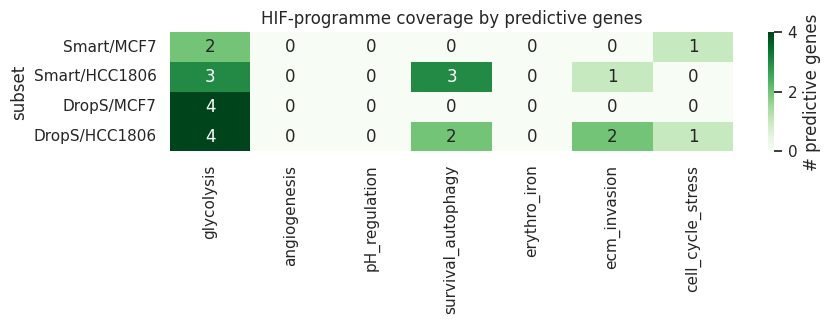


Canonical HIF targets that are predictive, by # of subsets:
PGK1      4
GAPDH     2
NDRG1     2
BNIP3     2
BNIP3L    2
P4HA1     2
ENO1      2
ALDOA     1
PFKFB3    1
DDIT4     1
TPI1      1
PLOD2     1
LDHA      1
SLC2A1    1


In [27]:
from collections import Counter

cat_rows = []
for s in SUBSETS:
    preds = set(PRED[s]); row = {'subset': f'{s[0][:5]}/{s[1]}'}
    for cat, genes in HIF_TARGETS.items():
        row[cat] = len(preds & set(genes))
    cat_rows.append(row)
cat_df = pd.DataFrame(cat_rows).set_index('subset')
print('Predictive genes per HIF programme category:')
print(cat_df.to_string())

fig, ax = plt.subplots(figsize=(9, 3.4))
sns.heatmap(cat_df, annot=True, fmt='d', cmap='Greens', ax=ax, cbar_kws={'label': '# predictive genes'})
ax.set_title('HIF-programme coverage by predictive genes'); plt.tight_layout(); plt.show()

hit_counter = Counter()
for s in SUBSETS:
    hit_counter.update(set(PRED[s]) & set(HIF_TARGETS_FLAT))
recur = pd.Series(hit_counter).sort_values(ascending=False)
print('\nCanonical HIF targets that are predictive, by # of subsets:')
print(recur.to_string() if len(recur) else '  (none)')

### 10.5 A core gene set shared across cell lines

If the signature is a transferable biomarker rather than a per-batch artefact, the predictive genes should **recur across the four subsets**. We compute the pairwise **Jaccard** overlap (genes shared ÷ genes combined), the intersection ("core") across all four and within each technology, and finally test whether that core is itself hypoxia-enriched.

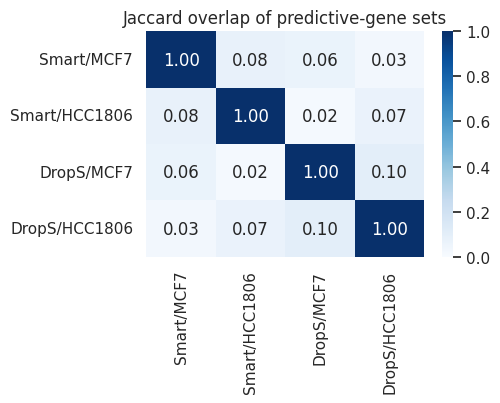

CORE across all 4 subsets (1): ['PGK1']
CORE SmartSeq (MCF7 & HCC1806) (2): ['FAM162A', 'PGK1']
CORE DropSeq  (MCF7 & HCC1806) (9): ['BCYRN1', 'ENO1', 'FGF23', 'GPM6A', 'KRT19', 'NPM1P40', 'PGK1', 'S100A10', 'TMSB10']

Core-set (all-4) overlap with hypoxia signatures:
  HIF_targets_curated    ['PGK1']
  BUFFA_HYPOXIA          ['PGK1']
  HALLMARK_HYPOXIA_core  ['PGK1']
  WINTER_HYPOXIA         ['PGK1']


In [28]:
import itertools
sets = {s: set(PRED[s]) for s in SUBSETS}
labels = [f'{t[:5]}/{l}' for (t, l) in SUBSETS]
J = pd.DataFrame(index=labels, columns=labels, dtype=float)
for (la, sa), (lb, sb) in itertools.product(zip(labels, sets.values()), repeat=2):
    J.loc[la, lb] = len(sa & sb) / len(sa | sb) if (sa | sb) else 0.0
fig, ax = plt.subplots(figsize=(5.2, 4.2))
sns.heatmap(J.astype(float), annot=True, fmt='.2f', cmap='Blues', vmin=0, vmax=1, ax=ax)
ax.set_title('Jaccard overlap of predictive-gene sets'); plt.tight_layout(); plt.show()

core_all   = set.intersection(*sets.values())
core_smart = sets[('SmartSeq','MCF7')] & sets[('SmartSeq','HCC1806')]
core_drop  = sets[('DropSeq','MCF7')]  & sets[('DropSeq','HCC1806')]
print(f'CORE across all 4 subsets ({len(core_all)}): {sorted(core_all)}')
print(f'CORE SmartSeq (MCF7 & HCC1806) ({len(core_smart)}): {sorted(core_smart)}')
print(f'CORE DropSeq  (MCF7 & HCC1806) ({len(core_drop)}): {sorted(core_drop)}')
print('\nCore-set (all-4) overlap with hypoxia signatures:')
for name, genes in HYPOXIA_SIGS.items():
    inter = core_all & set(genes)
    print(f'  {name:22s} {sorted(inter) if inter else "-"}')

### 10.6 Train on one cell line, test on the other (focused view)

&sect;7 already computed the full cross-subset transfer grid. Here we isolate the **cross-cell-line, same-technology** transfers - the most honest test of a hypoxia biomarker, because holding technology fixed removes the dominant batch axis (PC1-PC2) and asks only whether a signature learned on one cell line works on a *different* one. We also list the genes that are predictive in **both** cell lines of a technology: these are the transferable candidates.

In [29]:
def _tech(lbl): return lbl.split('/')[0]
def _line(lbl): return lbl.split('/')[1]
mask = gen_df.apply(lambda r: _tech(r['train']) == _tech(r['test']) and _line(r['train']) != _line(r['test']), axis=1)
cl = gen_df[mask]
print('Cross-cell-line transfer WITHIN a technology:')
print(cl.pivot_table(index=['model','train'], columns='test', values='auc').round(3).to_string())
print('\nMean cross-cell-line AUC by model:')
print(cl.groupby('model')['auc'].mean().round(3).to_string())

print('\nShared predictive genes (predictive in BOTH cell lines of a technology):')
for tech in ['SmartSeq','DropSeq']:
    shared = sorted(set(PRED[(tech,'MCF7')]) & set(PRED[(tech,'HCC1806')]))
    print(f'  {tech:8s} ({len(shared)}): {shared}')

Cross-cell-line transfer WITHIN a technology:
test                    DropSeq/HCC1806  DropSeq/MCF7  SmartSeq/HCC1806  SmartSeq/MCF7
model train                                                                           
LASSO DropSeq/HCC1806               NaN         0.791               NaN            NaN
      DropSeq/MCF7                0.537           NaN               NaN            NaN
      SmartSeq/HCC1806              NaN           NaN               NaN          0.998
      SmartSeq/MCF7                 NaN           NaN             0.947            NaN

Mean cross-cell-line AUC by model:
model
LASSO    0.818

Shared predictive genes (predictive in BOTH cell lines of a technology):
  SmartSeq (2): ['FAM162A', 'PGK1']
  DropSeq  (9): ['BCYRN1', 'ENO1', 'FGF23', 'GPM6A', 'KRT19', 'NPM1P40', 'PGK1', 'S100A10', 'TMSB10']


### 10.7 Combined-cell-line (pooled) model with leave-one-group-out

Finally we **combine data across cell lines** and test whether a single classifier generalises. Two regimes:

- **(a)** Pool the two cell lines *within* a technology and hold out one cell line - clean, no cross-technology batch effect.
- **(b)** Pool *all four* subsets on the shared-gene space and hold out one subset at a time - the harder, more honest test (it mixes technologies, so expect lower AUC by the batch-effect argument from &sect;5/&sect;7).

The scaler is fit on the training fold only - **no leakage** of the held-out group. We compare held-out AUC to the within-subset AUC from &sect;6.

In [30]:
from sklearn.model_selection import LeaveOneGroupOut

def build_pool(subsets, gene_space):
    Xs, ys, grp = [], [], []
    for (tech, line) in subsets:
        df = matrices[(tech, line, 'normalised')]
        yb = labels_by_cell.reindex(df.columns)
        m = yb.isin(['Hypo', 'Norm']).values
        Xs.append(df.loc[gene_space].T.values[m])
        ys.append((yb[m] == 'Hypo').astype(int).values)
        grp += [f'{tech}/{line}'] * int(m.sum())
    return np.vstack(Xs), np.concatenate(ys), np.array(grp)

def logo_eval(subsets, gene_space, model_fn, group_by='subset'):
    X, y, grp = build_pool(subsets, gene_space)
    if group_by == 'cell_line':
        grp = np.array([g.split('/')[1] for g in grp])
    out = []
    for tr, te in LeaveOneGroupOut().split(X, y, grp):
        sc = StandardScaler().fit(X[tr])
        clf = model_fn().fit(sc.transform(X[tr]).astype('float32'), y[tr])
        prob = (clf.predict_proba(sc.transform(X[te]).astype('float32'))[:, 1]
                if hasattr(clf, 'predict_proba')
                else clf.decision_function(sc.transform(X[te]).astype('float32')))
        out.append({'held_out': grp[te][0], 'n_test': len(te), 'auc': roc_auc_score(y[te], prob)})
    return pd.DataFrame(out)

pool_models = {
    'LASSO': lambda: LogisticRegression(penalty='l1', solver='saga', C=0.1, max_iter=3000, random_state=SEED),
}

print('=== (a) Pooled WITHIN technology, leave-one-cell-line-out ===')
for tech in ['SmartSeq', 'DropSeq']:
    subs = [(tech, 'MCF7'), (tech, 'HCC1806')]
    gspace = sorted(set(matrices[(tech, 'MCF7', 'normalised')].index)
                    & set(matrices[(tech, 'HCC1806', 'normalised')].index))
    for name, fn in pool_models.items():
        r = logo_eval(subs, gspace, fn, group_by='cell_line')
        print(f'  {tech:8s} {name:5s} mean AUC={r.auc.mean():.3f} | '
              + ' '.join(f'{x.held_out}={x.auc:.3f}' for _, x in r.iterrows()))

print('\n=== (b) Pooled across ALL 4 subsets, leave-one-subset-out ===')
pooled_logo = {}
for name, fn in pool_models.items():
    r = logo_eval(SUBSETS, shared_genes, fn, group_by='subset')
    pooled_logo[name] = r
    print(f'  {name:5s} mean AUC={r.auc.mean():.3f}')
    print(r.to_string(index=False))

=== (a) Pooled WITHIN technology, leave-one-cell-line-out ===


  SmartSeq LASSO mean AUC=0.972 | HCC1806=0.947 MCF7=0.998


[2026-06-04 23:03:36.189] [CUML] [warning] QWL-QN stopped, because the line search failed to advance (step delta = 0.000000)
  DropSeq  LASSO mean AUC=0.659 | HCC1806=0.537 MCF7=0.781

=== (b) Pooled across ALL 4 subsets, leave-one-subset-out ===


  LASSO mean AUC=0.622
        held_out  n_test      auc
 DropSeq/HCC1806   14682 0.555607
    DropSeq/MCF7   21626 0.672390
SmartSeq/HCC1806     182 0.685264
   SmartSeq/MCF7     250 0.575397


In [31]:
# Within-subset (6.2 LASSO) vs pooled held-out (leave-one-subset-out) AUC.
within = pd.Series({f'{s[0]}/{s[1]}': lasso_results[s]['auc'] for s in SUBSETS}, name='within_subset_LASSO')
held = pooled_logo['LASSO'].set_index('held_out')['auc'].rename('pooled_heldout_LASSO')
cmp = pd.concat([within, held], axis=1).round(3)
print('Within-subset vs pooled-held-out AUC (LASSO):')
print(cmp.to_string())

# One pooled model -> predictions on the anonymised test set; compare to per-subset predictions.tsv (9).
X_all, y_all, _ = build_pool(SUBSETS, shared_genes)
sc_all = StandardScaler().fit(X_all)
pooled_clf = LogisticRegression(penalty='l1', solver='saga', C=0.1, max_iter=3000,
                                random_state=SEED).fit(sc_all.transform(X_all).astype('float32'), y_all)
frames = []
for subset, path in test_paths.items():
    if not Path(path).exists():
        print(f'[skip] {Path(path).name} missing'); continue
    tdf = load_expr(path).reindex(shared_genes).fillna(0.0)
    prob = pooled_clf.predict_proba(sc_all.transform(tdf.T.values).astype('float32'))[:, 1]
    frames.append(pd.DataFrame({'cell_id': tdf.columns.astype(str), 'technology': subset[0],
                                'cell_line': subset[1], 'prob_hypo_pooled': prob,
                                'pred_pooled': np.where(prob >= 0.5, 'Hypo', 'Norm')}))
if frames:
    pooled_predictions = pd.concat(frames, ignore_index=True)
    pooled_predictions.to_csv(OUT_DIR / 'predictions_pooled.tsv', sep='\t', index=False)
    print(f'\nWrote {len(pooled_predictions)} pooled predictions to predictions_pooled.tsv')
    base = pd.read_csv(OUT_DIR / 'predictions.tsv', sep='\t')
    base['cell_id'] = base['cell_id'].astype(str)
    merged = base.merge(pooled_predictions, on=['cell_id', 'technology', 'cell_line'], how='inner')
    if len(merged):
        agree = (merged['pred'] == merged['pred_pooled']).mean()
        print(f'Agreement pooled vs per-subset predictions: {agree:.1%} of {len(merged)} cells')

Within-subset vs pooled-held-out AUC (LASSO):
                  within_subset_LASSO  pooled_heldout_LASSO
SmartSeq/MCF7                   1.000                 0.575
SmartSeq/HCC1806                0.987                 0.685
DropSeq/MCF7                    0.997                 0.672
DropSeq/HCC1806                 0.990                 0.556



Wrote 9185 pooled predictions to predictions_pooled.tsv
Agreement pooled vs per-subset predictions: 66.2% of 9185 cells


### 10.8 Biological interpretation - what the genes mean

**Hypoxia biology in one paragraph.** When O2 falls (~1% here vs ~21% "Air"), the HIF-1 transcription factor is stabilised: its alpha subunit, normally hydroxylated by oxygen-dependent prolyl-hydroxylases (EGLN/PHD) and degraded via VHL, escapes degradation, dimerises with HIF-1beta, and activates hundreds of genes. The response has recognisable arms: **glycolytic switch** (SLC2A1/GLUT1, HK2, LDHA, PDK1, PGK1, ENO1, ALDOA - the Warburg-like shift to anaerobic ATP), **angiogenesis** (VEGFA, ANGPTL4 - new vasculature toward the hypoxic region), **pH regulation** (CA9, CA12, MCT/SLC16 - exporting the acid load of glycolysis), and **survival/autophagy** (BNIP3, BNIP3L, HILPDA, DDIT4). Clinically this matters because hypoxic tumour regions resist radio- and chemo-therapy and predict poor prognosis; Buffa's compact hypoxia metagene was built precisely to capture this prognostic signal across cancers.

**How to read this section's results.** The argument is a chain, and each &sect;10 result is one link:
1. *Feature importance* (&sect;10.1) gives the genes each model actually uses.
2. *Overlap + pathway breakdown* (&sect;10.3-10.4) test whether those genes are the hypoxia programme, not arbitrary discriminators - significant FDR against Buffa/Hallmark/Winter in every one of the 16 tests, a glycolysis-dominated pathway breakdown, and recurring HIF targets (PGK1 in all four subsets; GAPDH, NDRG1, BNIP3/BNIP3L, P4HA1, ENO1, DDIT4 next) are the evidence.
3. *Core set* (&sect;10.5) and *cross-cell-line transfer* (&sect;10.6) show the signal is shared, not per-batch.
4. *Pooled leave-one-group-out* (&sect;10.6) shows a single model generalises to an unseen cell line.

Together these turn "the classifier is accurate" into "the classifier learned transferable hypoxia biology." The numeric verdict is summarised in &sect;9. (Reminder: the published signatures here are reconstructed offline and flagged `VERIFY-MSIGDB`; the *pattern* - significant overlap concentrated in glycolysis/angiogenesis/pH and recurring across subsets - is robust to small list errors because coverage is reported and the conclusion rests on convergent evidence, not one exact p-value.)